In [2]:
import modin.pandas as pd
from Functions import *
from Telescope import *

setTargetList("ML_list_jovians")
import Ariel

import warnings
warnings.filterwarnings('ignore')


from scipy import stats

________________________________________________________________
Opening all instruments into dictionary object 'instruments'...

Ariel
________________________________________________________________



In [3]:
# opendf = pd.read_csv("target_lists/ML_targetlist_level1_cleaned.csv")
aux = pd.read_csv("target_lists/AuxillaryTable.csv")
opendf = pd.read_csv("target_lists/FM_Parameter_Table.csv")

In [4]:
# aux["Transit Duration [hrs]"] = aux["planet_orbital_period"]*24 / np.pi * np.arcsin((aux["planet_radius_m"] + aux["star_radius_m"]) / (aux["planet_distance"]*1.496e11))
# aux = aux[aux["Transit Duration [hrs]"].notna()]

# cleanaux = cleanTargetList(aux, separate_errors=False)

cleanaux = pd.read_csv("target_lists/AuxillaryTableCleaned.csv")

In [5]:
jupitermasshalf = 1.898e27 / 2

In [66]:
quartiles = pd.read_csv("target_lists/QuartilesTable.csv")
print(f"Target count: {quartiles.shape[0]}")

Target count: 91392


In [75]:
df = pd.concat([opendf, quartiles, cleanaux], axis=1)
df = df.dropna(subset=["log_H2O_q1"])
df

,planet_ID,planet_temp,log_H2O,log_CO2,log_CH4,log_CO,log_NH3,planet_ID,T_q1,T_q2,...,planet_orbital_period,Planet Semi-major Axis [au],Planet Radius [Rjup],planet_surface_gravity,Transit Duration [hrs],Eclipse Duration [hrs],Mean Molecular Weight,Planet Albedo,Planet Geometric Albedo,Heat Redistribution Factor
0,0,1108.725067,-6.484809,-7.016512,-3.294729,-3.351913,-6.955828,0,1096.754060,1109.490687,...,3.646200,0.042501,0.250567,10.389141,2.763373,2.763373,2.3,0.2,0.25,0.8
1,1,636.858130,-8.829193,-8.603965,-5.501124,-4.799371,-6.020019,1,616.072976,636.977475,...,16.201656,0.114991,0.187339,11.315104,3.999224,3.999224,2.3,0.2,0.25,0.8
2,2,420.527609,-6.626830,-6.420932,-6.755727,-5.318471,-4.695118,2,411.059375,420.392211,...,88.406553,0.381830,0.376000,9.099284,8.454336,8.454336,2.3,0.2,0.25,0.8
3,3,1370.906116,-7.639372,-5.877303,-4.476840,-5.200010,-6.240726,3,1357.964612,1382.813499,...,3.575320,0.046513,1.007000,251.764117,3.233133,3.233133,2.3,0.2,0.25,0.8
4,4,746.170076,-4.172605,-6.899335,-6.360434,-4.140252,-8.896858,4,737.588375,746.177998,...,31.588900,0.196877,0.281000,9.919505,7.971695,7.971695,2.3,0.2,0.25,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21983,21983,568.279821,-7.843293,-7.253572,-7.395347,-5.899309,-5.672948,21983,561.177873,570.178023,...,3.692307,0.060678,1.266859,8.407069,2.657135,2.657135,2.3,0.2,0.25,0.8
21984,21984,570.943534,-5.013524,-4.875237,-3.845157,-3.377943,-6.271518,21984,551.195743,570.593837,...,54.418694,0.273359,0.271000,10.057574,7.901978,7.901978,2.3,0.2,0.25,0.8
21985,21985,473.760382,-7.166548,-8.755334,-7.775022,-4.570568,-7.281749,21985,474.249274,481.627181,...,4.783817,0.053979,1.032297,6.689611,3.796798,3.796798,2.3,0.2,0.25,0.8
21986,21986,694.894579,-5.418830,-6.053530,-8.875583,-3.035634,-7.147415,21986,690.315517,698.244198,...,127.833810,0.532155,0.543000,8.154318,12.072403,12.072403,2.3,0.2,0.25,0.8


In [76]:
df["log CO precision"] = (df["log_CO_q3"] - df["log_CO_q1"]) / 2
df["log CO2 precision"] = (df["log_CO2_q3"] - df["log_CO2_q1"]) / 2
df["log H2O precision"] = (df["log_H2O_q3"] - df["log_H2O_q1"]) / 2
df["log CH4 precision"] = (df["log_CH4_q3"] - df["log_CH4_q1"]) / 2
df["log NH3 precision"] = (df["log_NH3_q3"] - df["log_NH3_q1"]) / 2
df["T precision"] = (df["T_q3"] - df["T_q1"]) / 2

In [77]:
df["log CO accuracy"] = abs(df["log_CO_q2"] - df["log_CO"]) / df["log CO precision"]
df["log CO2 accuracy"] = abs(df["log_CO2_q2"] - df["log_CO2"]) / df["log CO2 precision"]
df["log H2O accuracy"] = abs(df["log_H2O_q2"] - df["log_H2O"]) / df["log H2O precision"]
df["log CH4 accuracy"] = abs(df["log_CH4_q2"] - df["log_CH4"]) / df["log CH4 precision"]
df["log NH3 accuracy"] = abs(df["log_NH3_q2"] - df["log_NH3"]) / df["log NH3 precision"]
df["T accuracy"] = abs(df["T_q2"] - df["planet_temp"]) / df["T precision"]

In [78]:
# df["log CO accuracy"] = np.log10(np.abs(10**df["log_CO"] - 10**df["log_CO_q2"]) / 10**df["log_CO"])
# df["log H2O accuracy"] = np.log10(np.abs(10**df["log_H2O"] - 10**df["log_H2O_q2"]) / 10**df["log_H2O"])
# df["log CH4 accuracy"] = np.log10(np.abs(10**df["log_CH4"] - 10**df["log_CH4_q2"]) / 10**df["log_CH4"])
# df["log CO2 accuracy"] = np.log10(np.abs(10**df["log_CO2"] - 10**df["log_CO2_q2"]) / 10**df["log_CO2"])
# df["log NH3 accuracy"] = np.log10(np.abs(10**df["log_NH3"] - 10**df["log_NH3_q2"]) / 10**df["log_NH3"])

In [79]:
# df["log CO precision"] = np.log10((10**df['log_CO_q3'] - 10**df['log_CO_q1']) / 2)
# df["log CO2 precision"] = np.log10((10**df['log_CO2_q3'] - 10**df['log_CO2_q1']) / 2)
# df["log H2O precision"] = np.log10((10**df['log_H2O_q3'] - 10**df['log_H2O_q1']) / 2)
# df["log CH4 precision"] = np.log10((10**df['log_CH4_q3'] - 10**df['log_CH4_q1']) / 2)
# df["log NH3 precision"] = np.log10((10**df['log_NH3_q3'] - 10**df['log_NH3_q1']) / 2)
# df["Temperature precision"] = (df['T_q3'] - df['T_q1']) / 2

In [80]:
# set plt resolution
plt.rcParams['figure.dpi'] = 200

-7.543724691698203


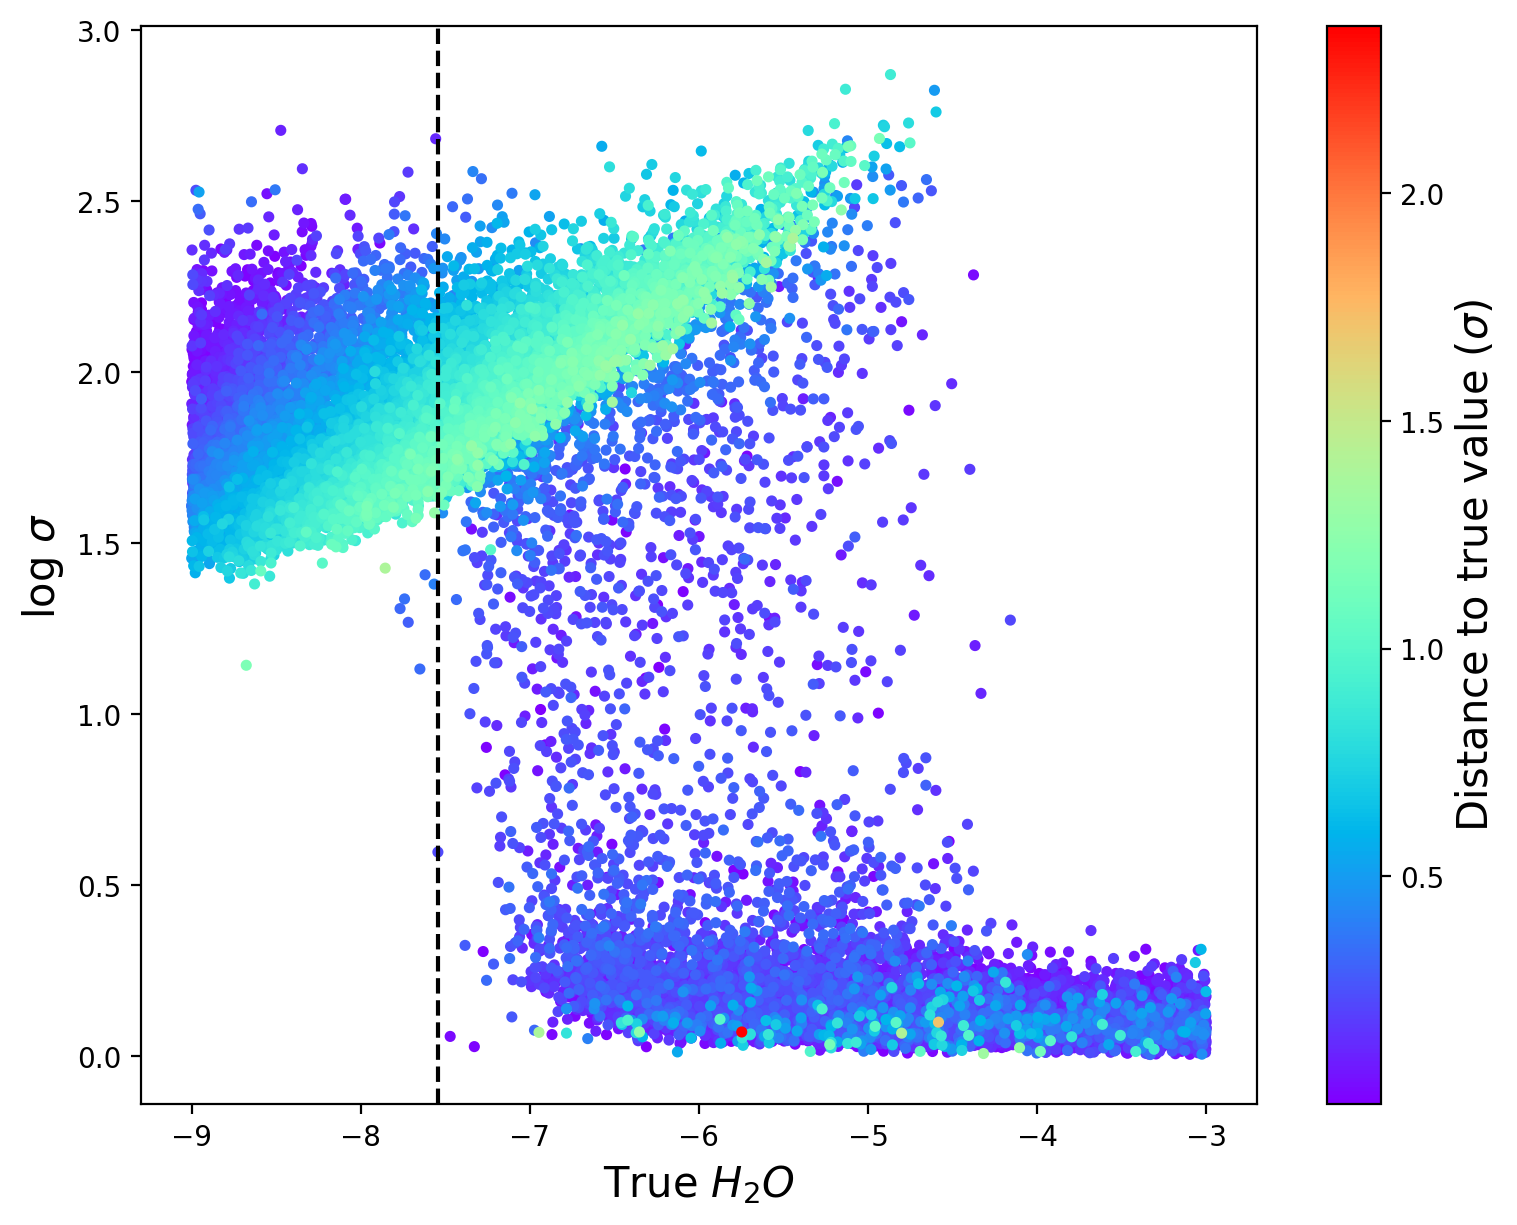

In [ ]:
fig, ax = plt.subplots(figsize=(9,7))

df_filtered = df.dropna(subset=["log H2O accuracy"])
df_filtered = df_filtered[df_filtered["log H2O accuracy"] < 3].sort_values("log H2O accuracy")

cax = ax.scatter(df_filtered["log_H2O"], (df_filtered['log_H2O_q3'] - df_filtered['log_H2O_q1'])/2, c=df_filtered["log H2O accuracy"], cmap="rainbow", label="H2O", marker='.')
plt.colorbar(cax).set_label(r"Distance to true value ($\sigma$)", size=15)

detection_limit = df_filtered[df_filtered["log H2O precision"] < 1]["log_H2O"].min()
print(detection_limit)
plt.axvline(detection_limit, color='black', linestyle='--', label="Detection limit")

# labels
plt.xlabel(r"True $H_2O$", fontsize=15)
plt.ylabel(r"log $\sigma$", fontsize=15)

plt.show()

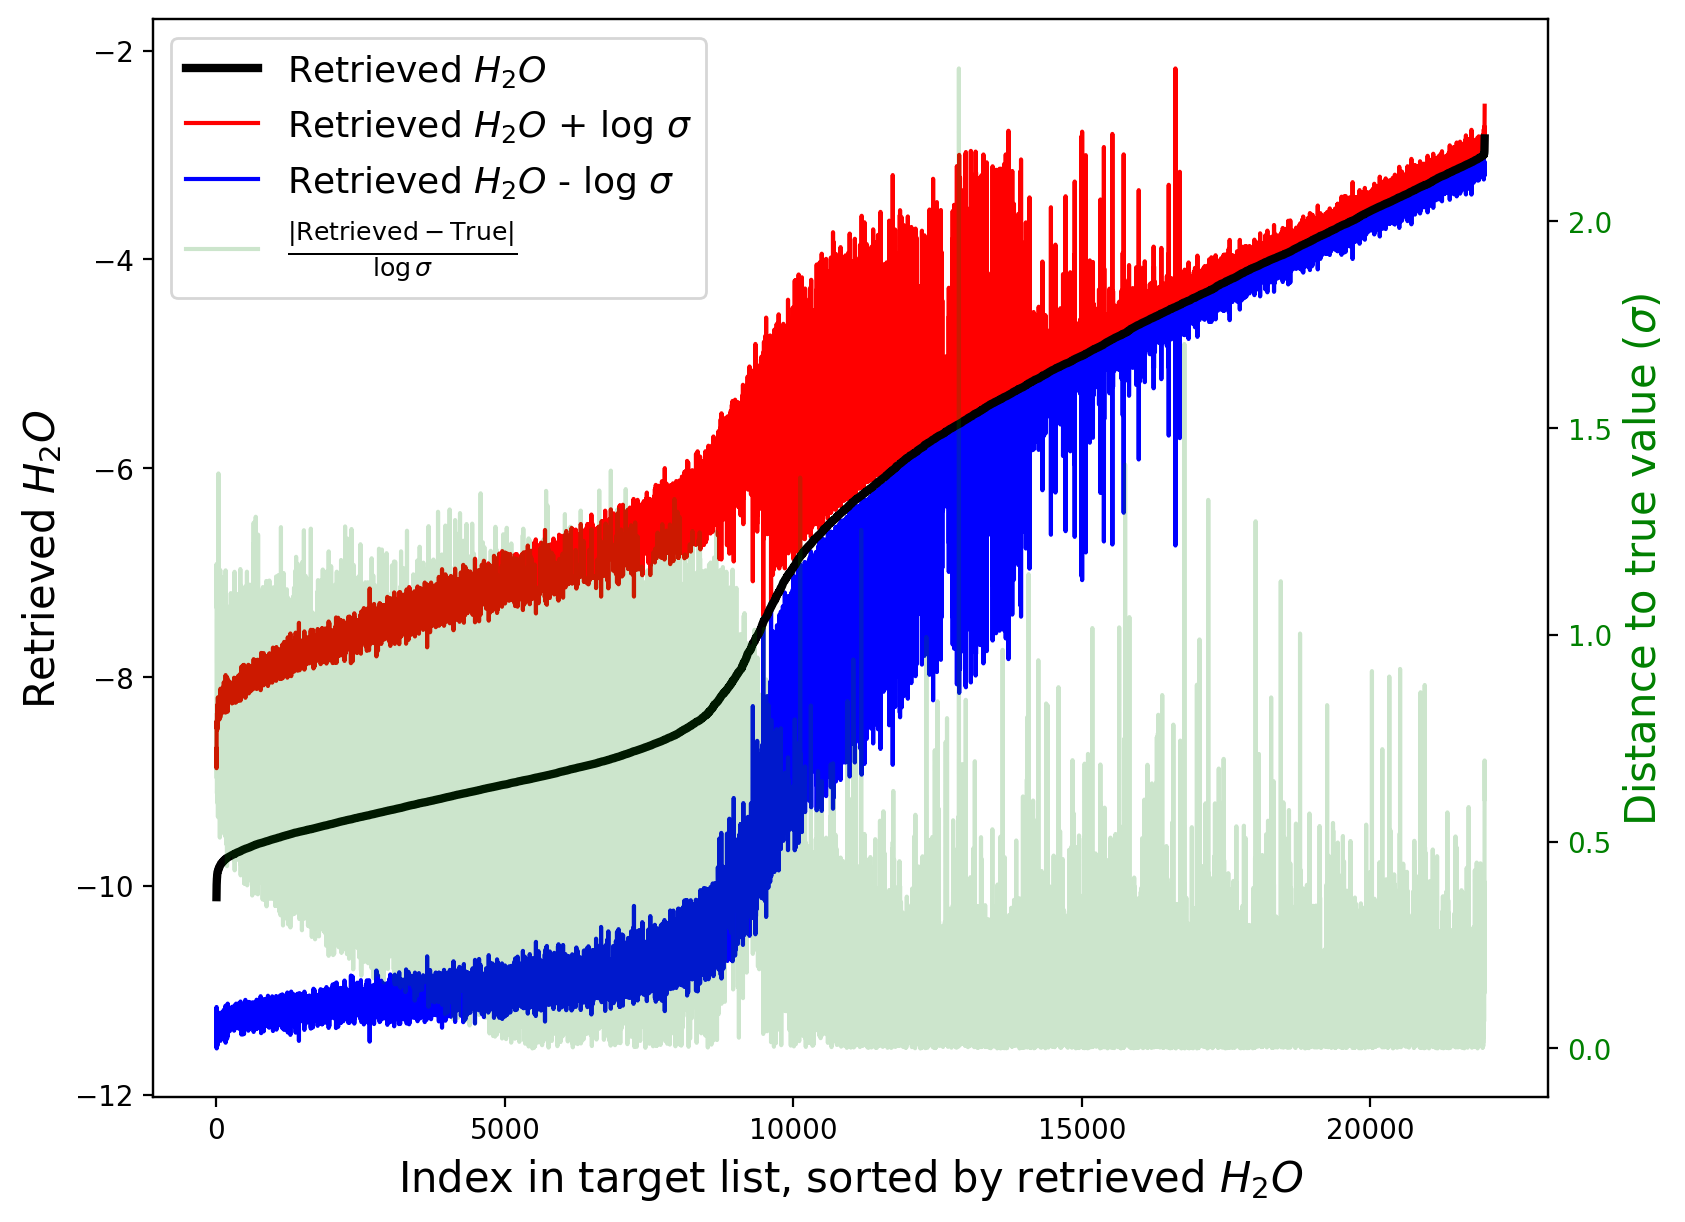

In [94]:
df_sorted = df.sort_values(by="log_H2O_q2", ascending=True)
df_sorted = df_sorted[df_sorted["log H2O accuracy"]<10]
df_sorted.reset_index(drop=True, inplace=True)

fig, ax = plt.subplots(figsize=(9,7))

ax.set_ylabel(r"Retrieved $H_2O$", fontsize=15)
ax.set_xlabel(r"Index in target list, sorted by retrieved $H_2O$", fontsize=15)

df_sorted["log_H2O_q2 + sigma"] = df_sorted["log_H2O_q2"] + df_sorted["log H2O precision"]
df_sorted["log_H2O_q2 - sigma"] = df_sorted["log_H2O_q2"] - df_sorted["log H2O precision"]


# df_sorted.plot(y="log_H2O_q1", use_index=True, ax=ax)
# df_sorted.plot(y="log_H2O_q3", use_index=True, ax=ax)
# df_sorted[:21700].plot(y="log_H2O", use_index=True, ax=ax)

df_sorted.plot(y="log_H2O_q2", use_index=True, ax=ax, color='black', linewidth=3, label=r"Retrieved $H_2O$", zorder=5, legend=False)
df_sorted.plot(y="log_H2O_q2 + sigma", use_index=True, ax=ax, color="red", label=r"Retrieved $H_2O$ + log $\sigma$", legend=False)
df_sorted.plot(y="log_H2O_q2 - sigma", use_index=True, ax=ax, color="blue", label=r"Retrieved $H_2O$ - log $\sigma$", legend=False)

ax1 = ax.twinx()
df_sorted[df_sorted["log H2O accuracy"]<10].plot(y="log H2O accuracy", use_index=True, ax=ax1, color="green", alpha=0.2, label=r"$\frac{|\text{Retrieved} - \text{True}|}{\log \sigma}$", legend=False)
ax1.set_ylabel(r"Distance to true value ($\sigma$)", color="green", fontsize=15)
ax1.tick_params(axis='y', labelcolor="green")

handles = []
labels = []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)
ax.legend(handles, labels, loc='upper left', fontsize=13)

plt.show()


In [95]:
def calculateTSM(tel, w_range):
    for wrange in w_range:
        
        tel.table["wrange"] = [(wrange[0], wrange[1])] * len(tel.table)
        
        w_range_name = f"{wrange[0]}-{wrange[1]}um"
        
        tel.table[f"Transit Flux Ratio {w_range_name}"] = 0
        tel.table[f"Noise Estimate {w_range_name}"] = 0
        tel.table[f"TSM Estimate {w_range_name}"] = 0
        
        for i, row in tel.table.iterrows():
                tel.table.loc[i, f"Transit Flux Ratio {w_range_name}"] = transitFlux(row["Planet Radius [Rjup]"],
                                                                        row["Star Radius [Rs]"],
                                                                        row["Planet Mass [Mjup]"],
                                                                        row["Dayside Emitting Temperature [K]"],
                                                                        row["Mean Molecular Weight"])
                
                tel.table.loc[i, f"Noise Estimate {w_range_name}"] = noiseEstimate(row["Star Temperature [K]"],
                                                                        row["wrange"],
                                                                        tel.throughput, 
                                                                        3*row["Transit Duration [hrs]"]*3600, # x3 Transit duration
                                                                        row["Star Radius [Rs]"],
                                                                        tel.diameter,
                                                                        row["Star Distance [pc]"])
                
        tel.table[f"TSM Estimate {w_range_name}"] = tel.table[f"Transit Flux Ratio {w_range_name}"] / tel.table[f"Noise Estimate {w_range_name}"]
        tel.table.drop(columns=["wrange"], inplace=True)
    
        
def getTSMs(tel):
    tel.table = tel.target_list.copy() # for calculations
    arr = tel.constructRanges() # getting wavelength ranges based on resolution
    calculateTSM(tel, arr)

In [17]:
# nir = Telescope("Ariel NIRSpec", 1, (1.10, 1.95), 10, 0.27, red, "reduced_ML_list")
# getTSMs(nir)
# a0 = Telescope("Ariel AIRS CH0", 1, (1.95, 3.9), 50, 0.18, red, "reduced_ML_list")
# getTSMs(a0)
# a1 = Telescope("Ariel AIRS CH1", 1, (3.9, 7.8), 10, 0.18, red, "reduced_ML_list")
# getTSMs(a1)

In [96]:
jovians = df[df["Planet Mass [Mjup]"] > 0.3]
jovians.reset_index(drop=True, inplace=True)
jovians.shape[0]

6149

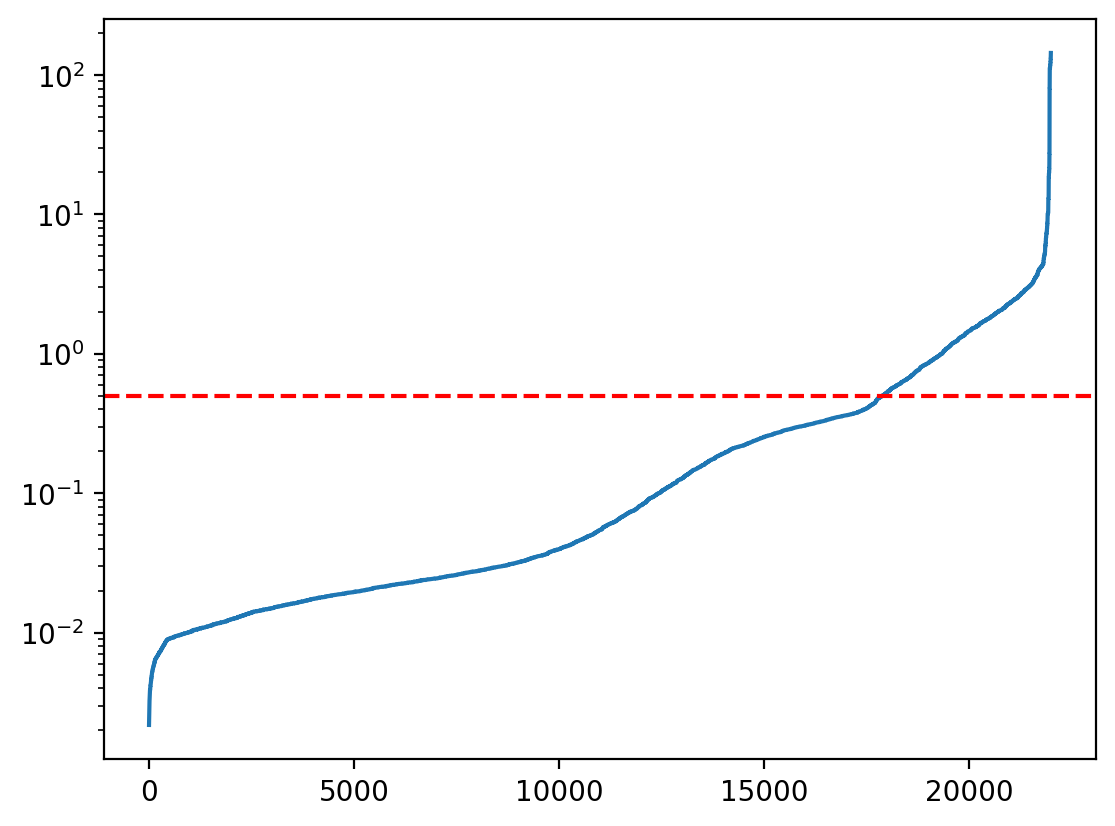

In [97]:
df.sort_values("Planet Mass [Mjup]")["Planet Mass [Mjup]"].reset_index(drop=True).plot()

plt.yscale("log")

plt.axhline(0.5, color='r', linestyle='--')

In [98]:
jovians.rename(columns={"planet_temp": "Dayside Emitting Temperature [K]",}, inplace=True)

In [65]:
nir = Telescope("Ariel NIRSpec", 1, (1.10, 1.95), 10, 0.27, jovians, "ML_list jovians")
getTSMs(nir)
a0 = Telescope("Ariel AIRS CH0", 1, (1.95, 3.9), 50, 0.18, jovians, "ML_list jovians")
getTSMs(a0)
a1 = Telescope("Ariel AIRS CH1", 1, (3.9, 7.8), 10, 0.18, jovians, "ML_list jovians")
getTSMs(a1)


jovians.to_csv("target_lists/ML_list_jovians.csv")

In [87]:
# # get average TSM for each planet
# tsms = pd.DataFrame()
# for tel in (nir, a0, a1):
#     for col in tel.table.columns:
#         if "TSM Estimate" in col:
#             tsms[col] = tel.table[col]

# red["Average TSM one transit"] = tsms.mean(axis=1)
# red["Observations"] = np.ceil((7 / red["Average TSM one transit"])**2)
# red["Average TSM"] = red["Average TSM one transit"] * red["Observations"]**0.5
# red


In [99]:
# get average TSM for each planet
tsms = pd.DataFrame()
for tel in (nir, a0, a1):
    for col in tel.table.columns:
        if "TSM Estimate" in col:
            tsms[col] = tel.table[col]

jovians.reset_index(drop=True, inplace=True)
jovians["Average TSM one transit"] = tsms.mean(axis=1)
jovians["Observations"] = np.ceil((7 / jovians["Average TSM one transit"])**2)
jovians["Average TSM"] = jovians["Average TSM one transit"] * jovians["Observations"]**0.5
jovians

,planet_ID,Dayside Emitting Temperature [K],log_H2O,log_CO2,log_CH4,log_CO,log_NH3,planet_ID,T_q1,T_q2,...,T precision,log CO accuracy,log CO2 accuracy,log H2O accuracy,log CH4 accuracy,log NH3 accuracy,T accuracy,Average TSM one transit,Observations,Average TSM
0,3,1370.906116,-7.639372,-5.877303,-4.476840,-5.200010,-6.240726,3,1357.964612,1382.813499,...,25.963922,0.916641,0.086576,0.582678,0.028907,0.750920,0.458613,0.031369,49795.0,7.000023
1,8,1894.426237,-4.563467,-4.446741,-5.544289,-4.365387,-8.544595,8,1861.275569,1898.283858,...,36.694649,0.936523,0.086624,0.133096,0.019386,0.235840,0.105128,1.086627,42.0,7.042150
2,9,1398.904600,-3.197861,-5.635948,-7.961980,-3.112749,-7.210507,9,1366.710997,1395.927137,...,29.623146,0.754298,0.144069,0.133072,0.838617,0.814615,0.100511,3.040484,6.0,7.447633
3,17,1300.997519,-7.775057,-7.049119,-4.199703,-4.026407,-8.030805,17,1279.438144,1300.503834,...,20.679611,0.316399,0.157338,0.722543,0.054296,0.746928,0.023873,3.394785,5.0,7.590970
4,18,1854.009915,-3.546382,-7.673770,-4.768994,-3.214935,-4.559483,18,1829.671342,1852.853390,...,24.626463,0.364011,0.740704,0.121995,0.149380,0.108036,0.046963,2.561749,8.0,7.245722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6144,21976,1678.181189,-7.401854,-8.511521,-4.984740,-3.686905,-7.802424,21976,1657.572451,1679.967163,...,21.742118,0.045828,0.915166,1.079705,0.033311,0.831045,0.082144,0.459809,232.0,7.003598
6145,21977,554.850619,-8.078990,-7.839560,-6.695415,-3.031263,-8.734446,21977,549.637457,556.061347,...,6.557614,0.031976,0.077972,0.983562,0.156180,0.533087,0.184629,0.302387,536.0,7.000761
6146,21982,1023.177585,-8.764363,-4.270897,-6.007470,-3.461416,-5.111242,21982,1000.397895,1022.772853,...,24.262374,0.263082,0.047759,0.307490,0.101626,0.023996,0.016681,0.478282,215.0,7.012990
6147,21983,568.279821,-7.843293,-7.253572,-7.395347,-5.899309,-5.672948,21983,561.177873,570.178023,...,9.067556,0.285330,0.142243,1.022147,0.665311,0.024911,0.209340,1.584371,20.0,7.085524


-7.177297112862299


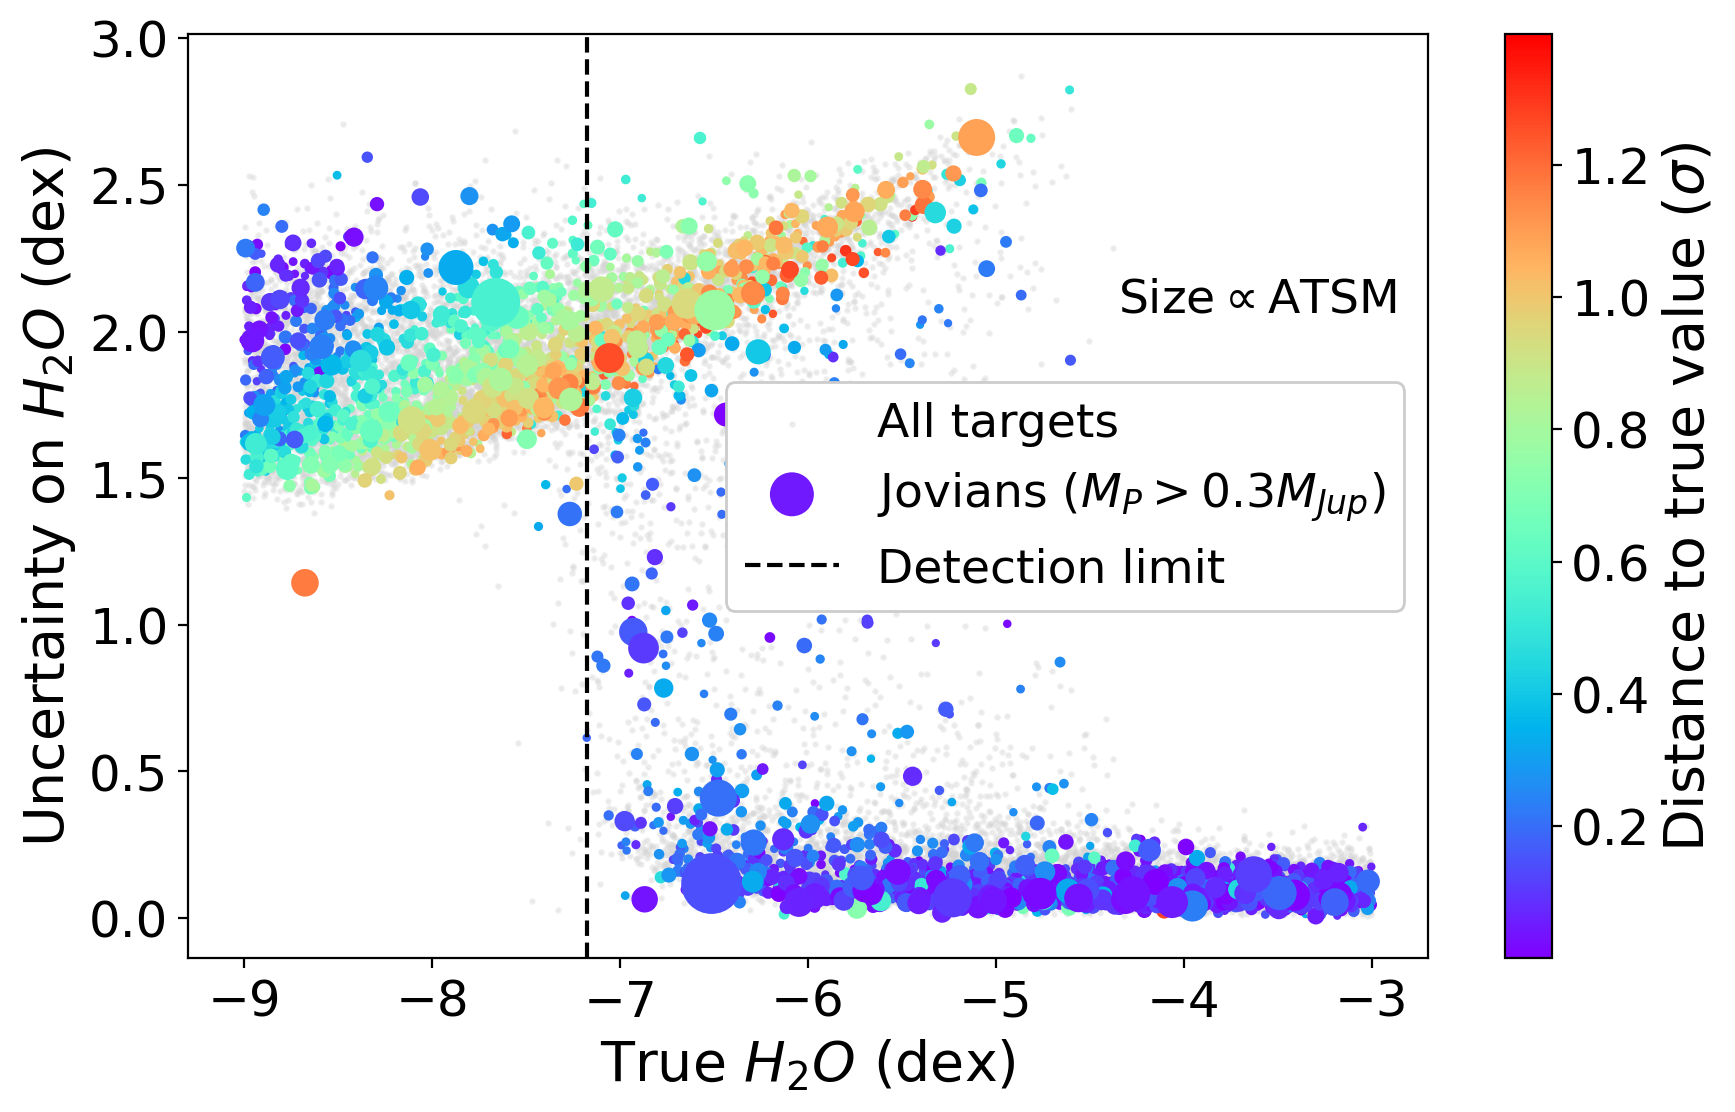

Total target count:  21982
Jovian target count:  6149


In [103]:
fig, ax = plt.subplots(figsize=(10,6))

fontsize = 20

j_filtered = jovians.dropna(subset=["log H2O accuracy"])
# j_filtered = j_filtered[j_filtered["Planet Radius [Rjup]"] > 0.5]
j_filtered = j_filtered[j_filtered["Observations"] < 50]
j_filtered = j_filtered[j_filtered["log H2O accuracy"] < 3].sort_values("Average TSM one transit")

ax.scatter(df_filtered["log_H2O"], 
                 (df_filtered['log_H2O_q3'] - df_filtered['log_H2O_q1'])/2, 
                 s = 8,
                 c="lightgrey", marker='.',
                 alpha=0.3, 
                 label="All targets")


cax = ax.scatter(j_filtered["log_H2O"], 
                 (j_filtered['log_H2O_q3'] - j_filtered['log_H2O_q1'])/2, 
                 s = j_filtered["Average TSM one transit"]*15,
                 c=j_filtered["log H2O accuracy"], cmap="rainbow", marker='.',
                 label=r"Jovians ($M_P > 0.3M_{Jup}$)")

cbar = plt.colorbar(cax)
cbar.set_label(r"Distance to true value ($\sigma$)", size=fontsize)
cbar.ax.tick_params(labelsize=fontsize-2)

detection_limit = j_filtered[j_filtered["log H2O precision"] < 1]["log_H2O"].min()
print(detection_limit)
plt.axvline(detection_limit, color='black', linestyle='--', label="Detection limit")

# labels
plt.xlabel(r"True $H_2O$ (dex)", fontsize=fontsize)
plt.ylabel(r"Uncertainty on $H_2O$ (dex)", fontsize=fontsize)
# plt.title("Relation between the uncertainty on the metallicity\nand the metallicity for a target", fontsize=17)

ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.text(0.75, 0.7, r"Size$\propto$ATSM", fontsize=fontsize-3, transform=ax.transAxes)
ax.legend(fontsize=fontsize-3, framealpha=1)

plt.show()

print("Total target count: ", df_filtered.shape[0])
print("Jovian target count: ", jovians.shape[0])

(0.11, 0.07)

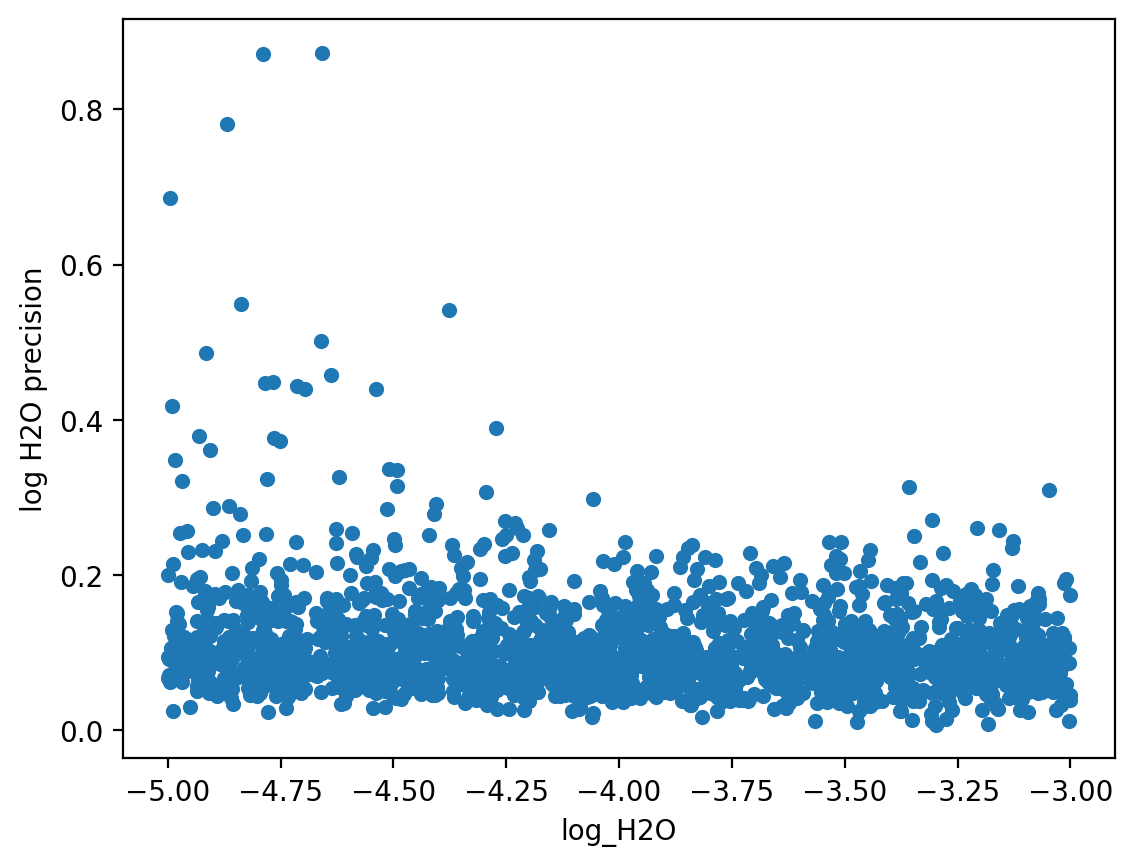

In [74]:
dfj = j_filtered[j_filtered["log_H2O"] > -5]
dfj = dfj[dfj["log H2O precision"] < 1]
dfj.plot(x="log_H2O", y="log H2O precision", kind="scatter")

round(dfj["log H2O precision"].mean(), 2), round(dfj["log H2O precision"].std(), 2)


We assume a linear relationship between the logarithm of the planet's period and its metallicity (in dex). We can set a slope of $a$ with an intercept $b$, thus the relationship can be written as follows:
$$M = a \log P + b.$$

If the planets underwent a high-eccentricity migration down to a period somewhere between 1-4 days, we can try to determine what initial period would they need to have to be resolved? In other words, what $P_i$ should these migrated planets have had such that we can differentiate them from those who follow the relationship with their current orbital periods? 

We can do this by defining the metallicity difference: $\Delta M$, between the migrated planet that had an initial period $P_i$ and some other target at a low orbital period $P_\text{low}$:

$$\Delta M = a \log P_i + b - (a \log P_\text{low} + b) = a ( \log P_i - \log P_\text{low} ) $$

To detect the difference, we require that $\Delta M$ be some number of times greater than the uncertainty on the metallicity $\sigma$. 

$$\Delta M > n\sigma \quad \implies \quad P_i > P_\text{low}10^{n\sigma / a} $$

Note that the $\sigma$ is determined by assuming that the metallicity of the planets are greater than $-5$ dex, such that $\sigma \sim 0.1$ dex. Also, we assume that $a \sim 0.13 \sim \sigma$. If $P_\text{low} \sim 1$ day, then we end up with the simple condition: 

$$P_i \gtrsim 10^n. $$

In other words, to possibly resolve the difference in metallicity for targets with the same current period (but where one may have underwent some migration) the initial period of the migrated planet must be on the order of $10^n$, where $n$ is the number of sigma desired in the detection.

\vspace{1em}

We can redo this exercise but with eccentricity instead, assuming high eccentricity migration. Recall that 
$$P_i = \frac{P_f}{(2(1-e_i))^{3/2}},$$
where $e_i$ is the initial eccentricity of the planet. Since $P_f$ should be the same as $P_\text{low}$ to detect the difference, we can do the following:

$$\Delta M = a (\log P_f - \frac{3}{2}\log(2(1-e_i)) - \log P_\text{low}) = - \frac{3}{2}a \log(2(1-e_i)),$$
and as before:
$$ n\sigma <  \Delta M \quad \implies \quad e_i > 1 - \frac{1}{2} 10^{-\frac{2}{3}n\sigma / a} \sim 1 - 10^{-n}$$

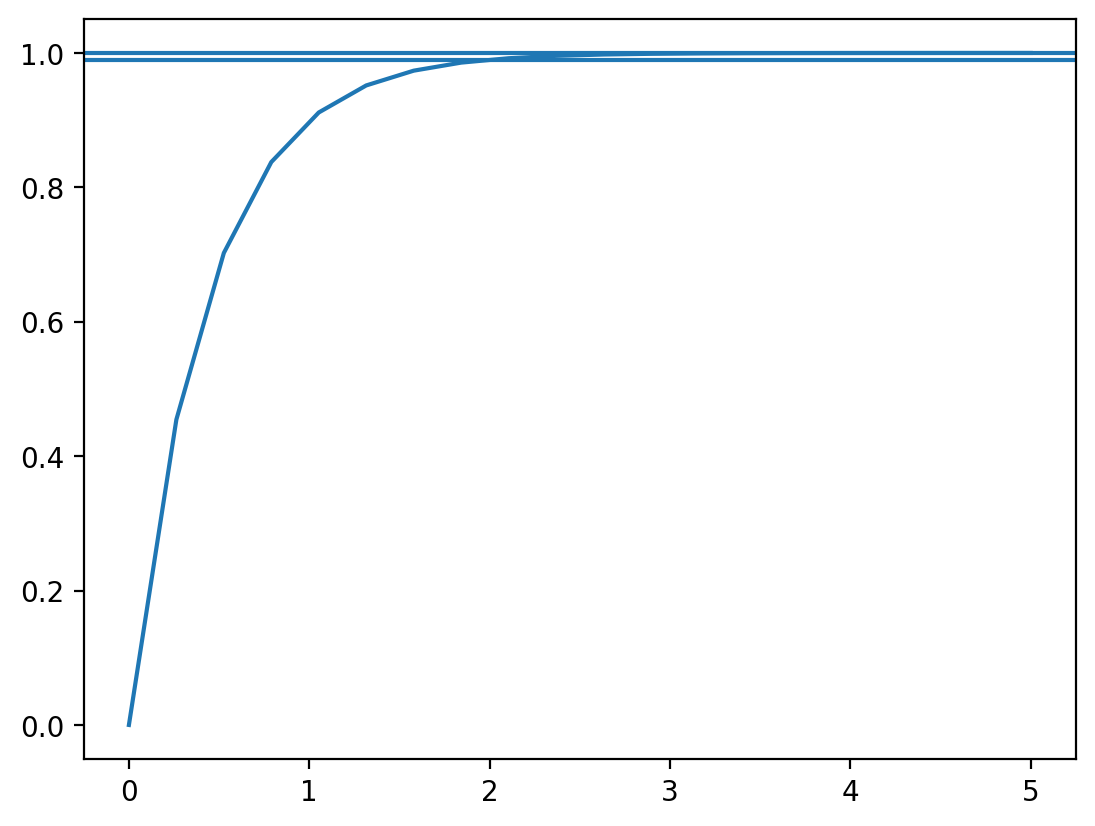

In [41]:
ntest = np.linspace(0, 5, 20)
plt.plot(ntest, 1-10**(-ntest))
plt.axhline(0.99)
plt.axhline(1)

In [25]:
j_filtered["log H2O precision"].min()

0.008088422350126967

In [425]:
test = list(zip(j_filtered["log_H2O"],
                              j_filtered["log_H2O_q2"],
                              j_filtered["log H2O precision"],
                              j_filtered["log H2O accuracy"]))

for x in test:
    if x[3] > 1 and x[0]>x[1] and (x[1]+x[2]) > x[0]:
        print(x[3] > 1 and x[0]<x[1] and (x[1]-x[2]) > x[0])
        break
# print(abs(test[0] - test[1]))
# print(abs(test[0] - test[1]) * test[2])
# print(test[1] + abs(test[0] - test[1]) * test[2])
# x[1]+x[2] > x[0]

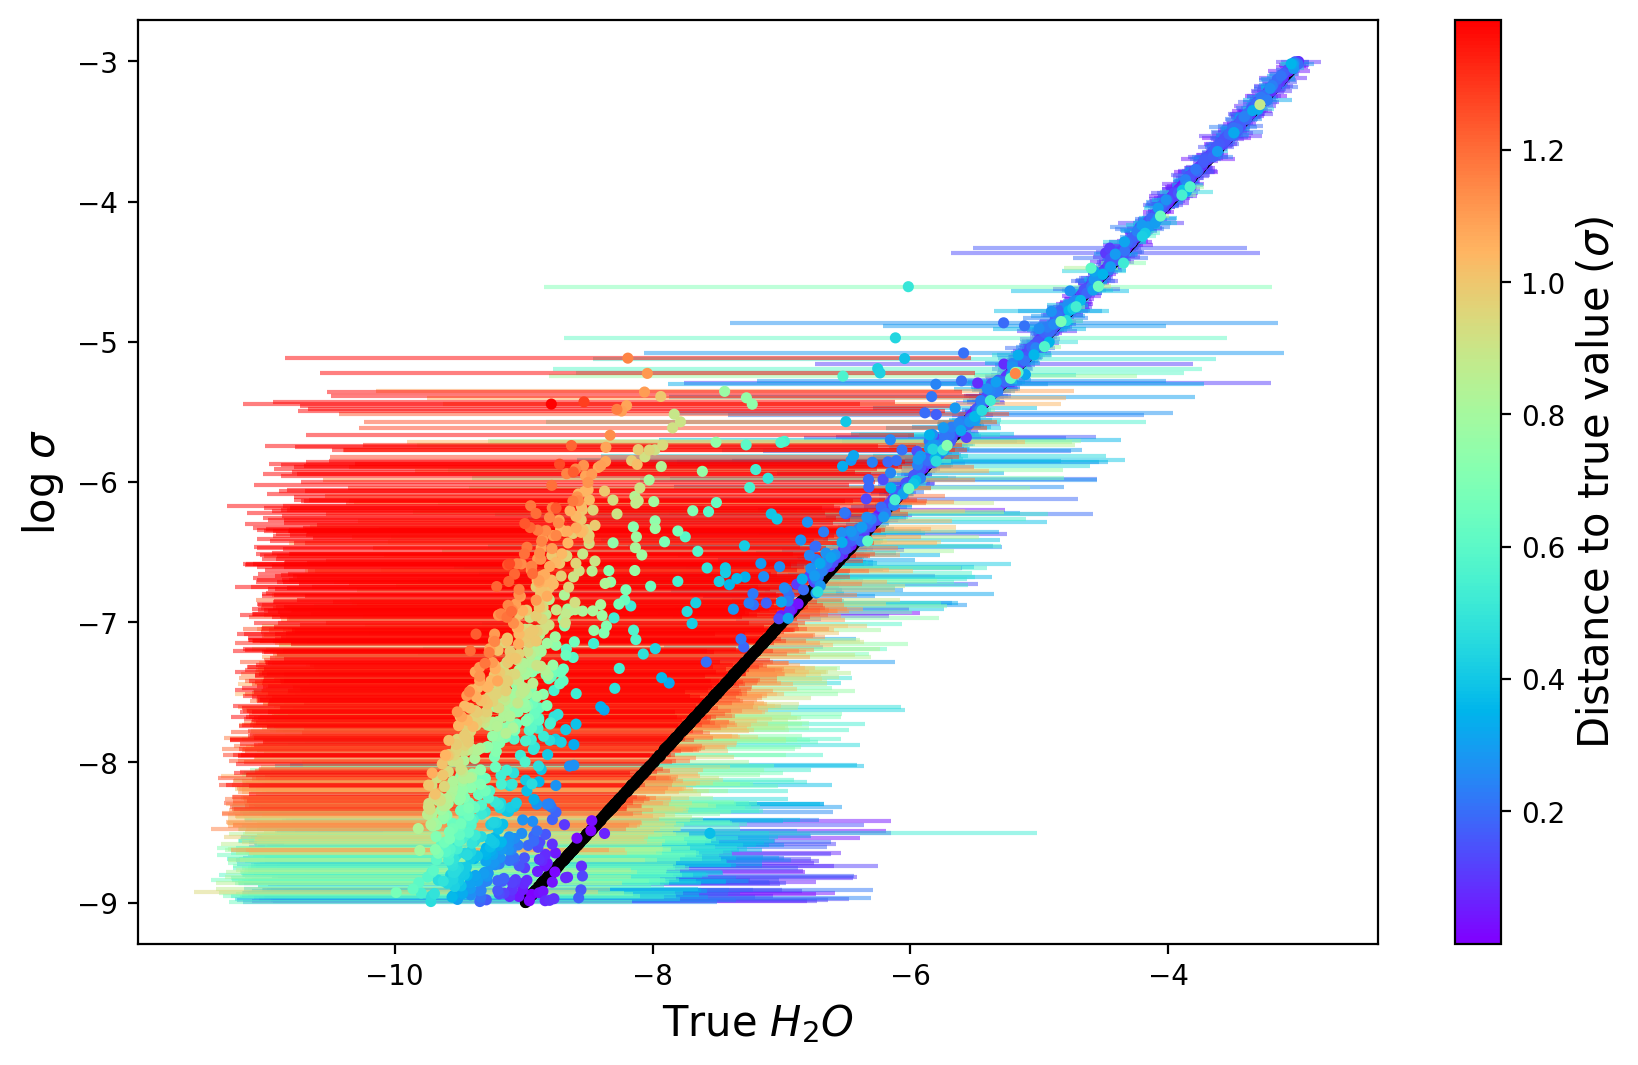

In [407]:
fig, ax = plt.subplots(figsize=(10,6))

j_filtered.sort_values("log H2O accuracy", inplace=True)

cmap = plt.get_cmap("rainbow")
color = cmap(j_filtered["log H2O accuracy"])


ax.errorbar(j_filtered["log_H2O_q2"], j_filtered["log_H2O"],
                  xerr=j_filtered["log H2O precision"],
                  ecolor = color,
                  fmt='.', markersize=0, alpha=0.5, label="Jovians")

cax = ax.scatter(j_filtered["log_H2O_q2"], 
                 j_filtered["log_H2O"],
                 c=j_filtered["log H2O accuracy"], cmap="rainbow", marker='.',
                 label=r"Jovians ($M_{Jup} > 0.5$)", zorder=5)

    
ax.plot(j_filtered["log_H2O"], j_filtered["log_H2O"], 'k.', zorder=4)


plt.colorbar(cax).set_label(r"Distance to true value ($\sigma$)", size=15)

# labels
plt.xlabel(r"True $H_2O$", fontsize=15)
plt.ylabel(r"log $\sigma$", fontsize=15)


plt.show()

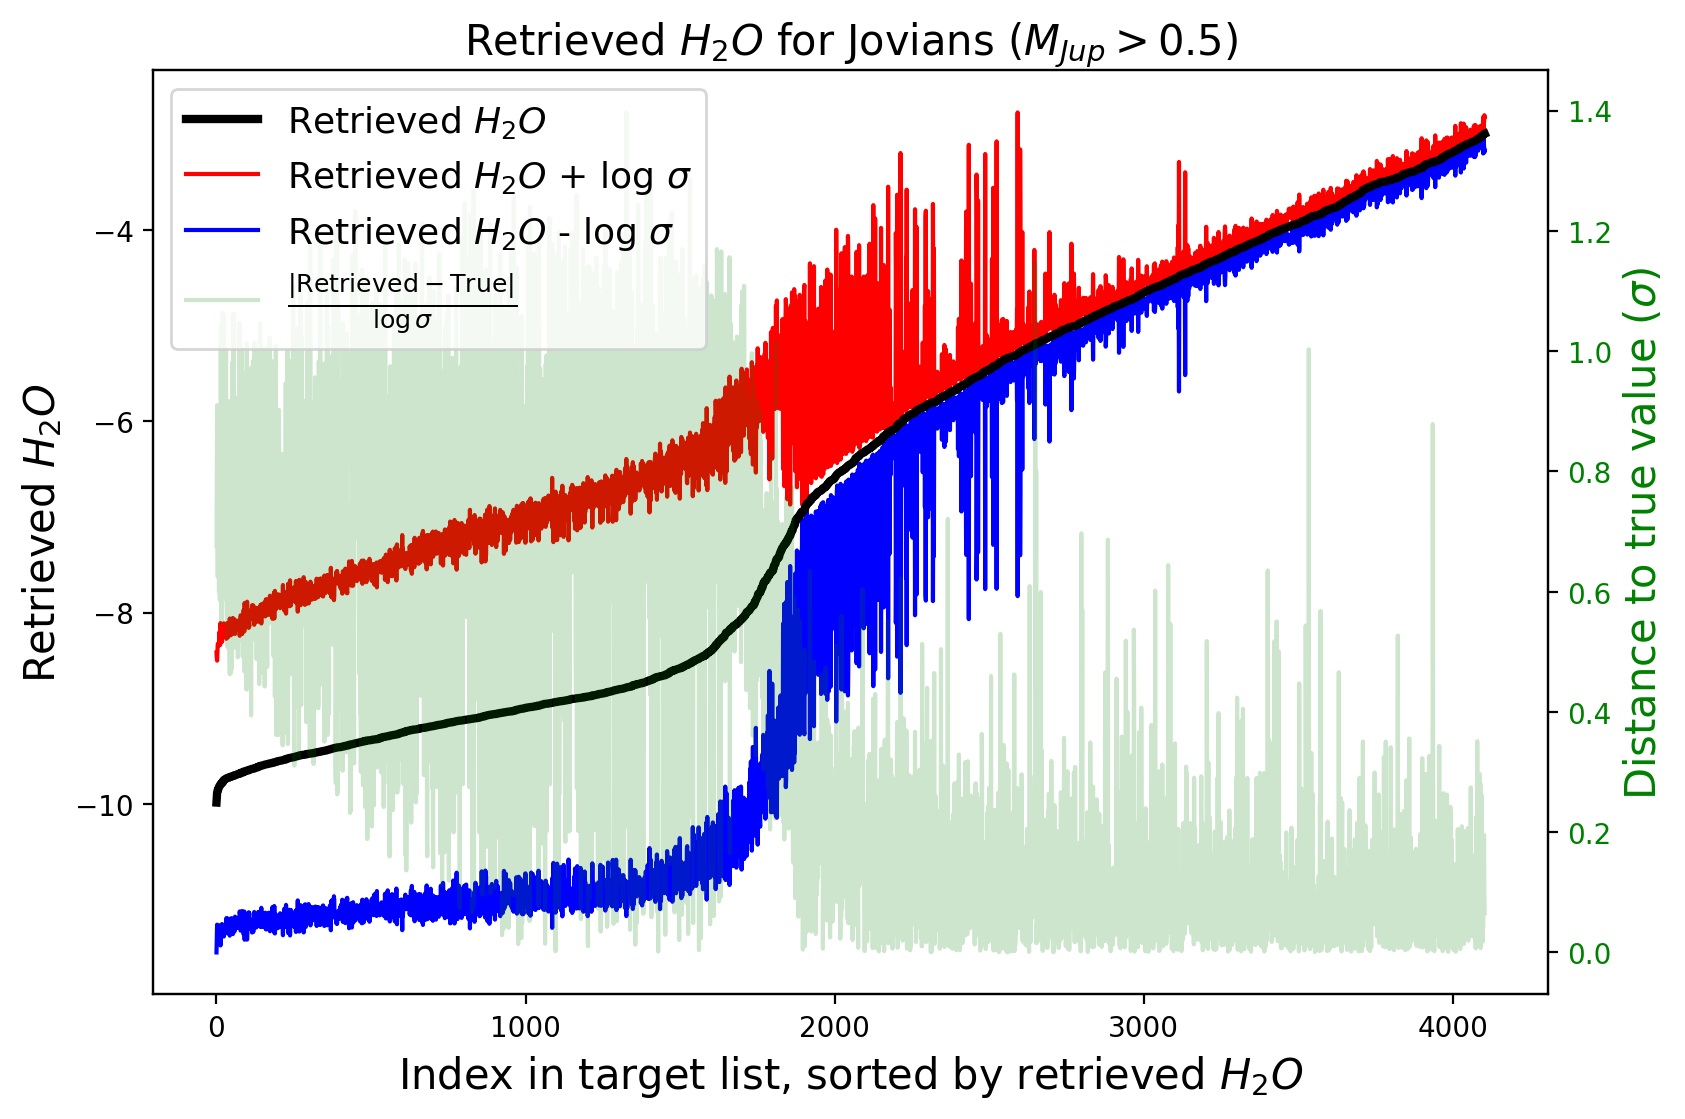

In [286]:
df_sorted = jovians.sort_values(by="log_H2O_q2", ascending=True)
df_sorted = df_sorted[df_sorted["log H2O accuracy"]<10]
df_sorted.reset_index(drop=True, inplace=True)

fig, ax = plt.subplots(figsize=(9,6))

ax.set_ylabel(r"Retrieved $H_2O$", fontsize=15)
ax.set_xlabel(r"Index in target list, sorted by retrieved $H_2O$", fontsize=15)

df_sorted["log_H2O_q2 + sigma"] = df_sorted["log_H2O_q2"] + df_sorted["log H2O precision"]
df_sorted["log_H2O_q2 - sigma"] = df_sorted["log_H2O_q2"] - df_sorted["log H2O precision"]


# df_sorted.plot(y="log_H2O_q1", use_index=True, ax=ax)
# df_sorted.plot(y="log_H2O_q3", use_index=True, ax=ax)
# df_sorted[:21700].plot(y="log_H2O", use_index=True, ax=ax)

df_sorted.plot(y="log_H2O_q2", use_index=True, ax=ax, color='black', linewidth=3, label=r"Retrieved $H_2O$", zorder=5, legend=False)
df_sorted.plot(y="log_H2O_q2 + sigma", use_index=True, ax=ax, color="red", label=r"Retrieved $H_2O$ + log $\sigma$", legend=False)
df_sorted.plot(y="log_H2O_q2 - sigma", use_index=True, ax=ax, color="blue", label=r"Retrieved $H_2O$ - log $\sigma$", legend=False)

ax1 = ax.twinx()
df_sorted[df_sorted["log H2O accuracy"]<10].plot(y="log H2O accuracy", use_index=True, ax=ax1, color="green", alpha=0.2, label=r"$\frac{|\text{Retrieved} - \text{True}|}{\log \sigma}$", legend=False)
ax1.set_ylabel(r"Distance to true value ($\sigma$)", color="green", fontsize=15)
ax1.tick_params(axis='y', labelcolor="green")

handles = []
labels = []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)
ax.legend(handles, labels, loc='upper left', fontsize=13)

ax.set_title("Retrieved $H_2O$ for Jovians ($M_{Jup} > 0.5$)", fontsize=15)

plt.show()

# Simulating line retrieval (H2O abundance vs period)

In [217]:
plt.rcParams['figure.dpi'] = 130

16486
17311


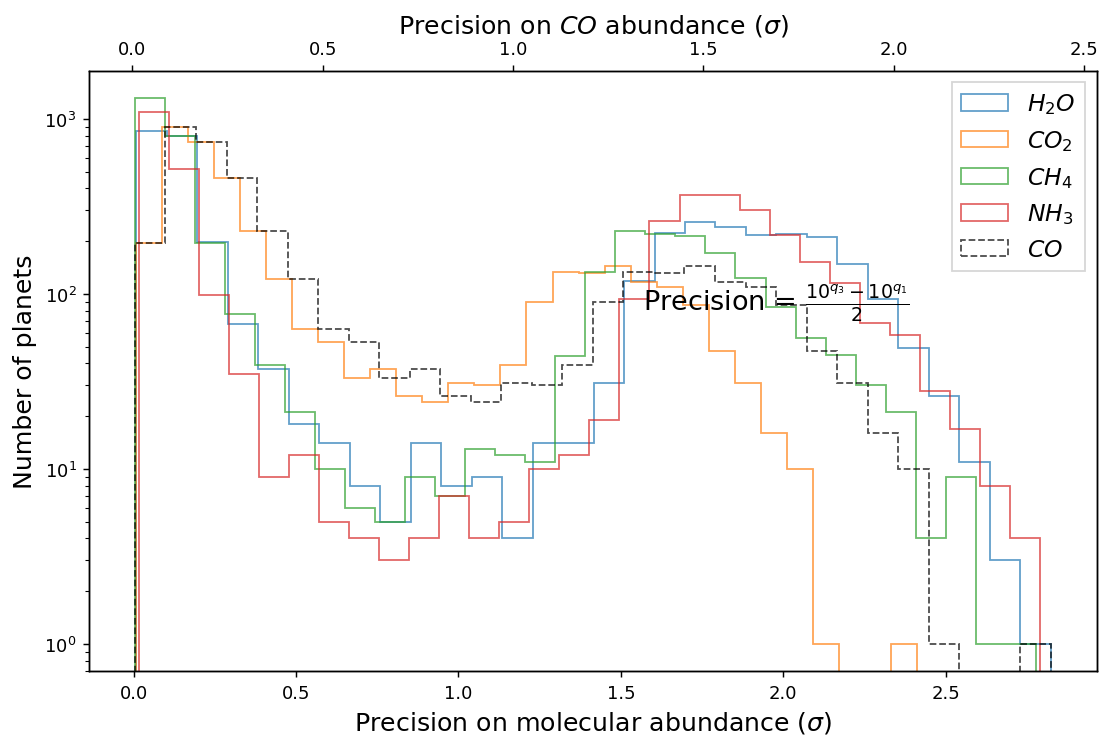

In [218]:
fig, ax = plt.subplots(figsize=(10, 6))

print(jovians[jovians["Observations"]>2].shape[0])
print(jovians.shape[0])

ax.hist(jovians[jovians["Observations"]>2]["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"$H_2O$")
ax.hist(jovians[jovians["Observations"]>2]["log CO2 precision"], bins=30, histtype='step', alpha=0.7, label=r"$CO_2$")
ax.hist(jovians[jovians["Observations"]>2]["log CH4 precision"], bins=30, histtype='step', alpha=0.7, label=r"$CH_4$")
ax.hist(jovians[jovians["Observations"]>2]["log NH3 precision"], bins=30, histtype='step', alpha=0.7, label=r"$NH_3$")
# ax.hist(jovians["log H2O precision"], bins=50, histtype='step')

ax1 = ax.twiny()
ax1.hist(jovians[jovians["Observations"]>2]["log CO2 precision"], bins=30, histtype='step', alpha=0.7, label=r"$CO$", color='k', linestyle='--')

#legend handles
handles, labels = ax.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
handles.extend(handles1)
labels.extend(labels1)
ax.legend(handles, labels, fontsize=13, fancybox=False)

ax.set_yscale('log')

ax.text(0.55, 0.6, r"Precision = $\frac{10^{q_3} - 10^{q_1}}{2}$", transform=ax.transAxes, fontsize=15)

ax.set_xlabel(r"Precision on molecular abundance ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)
ax1.set_xlabel(r"Precision on $CO$ abundance ($\sigma$)", fontsize=14, color='k')

plt.show()

In [1]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(jovians[jovians["Observations"]>2]["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"$H_2O$")

ax.set_yscale('log')

ax.set_title("Precision on H2O abundance", fontsize=15)

ax.set_xlabel(r"Water abundance precision ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)

ax.text(0.25, 0.45, r"$\log(H_2O) \pm \sigma$", transform=ax.transAxes, fontsize=15)

plt.show()

NameError: name 'plt' is not defined

In [292]:
def calculate_metrics_with_bootstrap(column, n_bootstrap=1000, confidence_level=0.95):
    # Drop NaN values to avoid issues
    precision_data = column.dropna()
    
    # Basic statistics
    mean = precision_data.mean()
    median = precision_data.median()
    std_dev = precision_data.std()
    n = len(precision_data)
    
    # Standard error of the mean
    sem = std_dev / np.sqrt(n)
    
    # Confidence interval for the mean (assuming normality)
    z = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    ci_lower = mean - z * sem
    ci_upper = mean + z * sem
    
    # Bootstrap for median confidence interval
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(precision_data, size=n, replace=True)
        bootstrap_medians.append(np.median(sample))
    median_ci_lower = np.percentile(bootstrap_medians, (1 - confidence_level) / 2 * 100)
    median_ci_upper = np.percentile(bootstrap_medians, (1 + confidence_level) / 2 * 100)
    
    # Return the results as a dictionary
    return {
        "Expected Precision (Mean)": mean,
        "Median Precision": median,
        "Median CI Lower": median_ci_lower,
        "Median CI Upper": median_ci_upper,
        "95% CI Lower (Mean)": ci_lower,
        "95% CI Upper (Mean)": ci_upper,
        "Standard Deviation": std_dev,
        "Targets considered": precision_data.shape[0]
    }

# Apply the function to precision columns
# Assuming `jovians` is a DataFrame with precision columns labeled appropriately
results = {
    col.split()[0]: calculate_metrics_with_bootstrap(jovians[col])
    for col in jovians.columns if "precision" in col.lower()
}

# Create a DataFrame to display the results
df_results = pd.DataFrame(results).T.reset_index()
df_results.rename(columns={"index": "Molecule"}, inplace=True)

# Display the resulting DataFrame
df_results.style.format(precision=2).set_table_attributes('style="display:inline"')

,Molecule,Expected Precision (Mean),Median Precision,Median CI Lower,Median CI Upper,95% CI Lower (Mean),95% CI Upper (Mean),Standard Deviation,Targets considered
0,log,-4.60,-4.62,-4.66,-4.57,-4.63,-4.58,0.84,4104.00
1,Temperature,636.36,558.91,549.48,569.45,625.30,647.42,361.57,4104.00


4104
4104


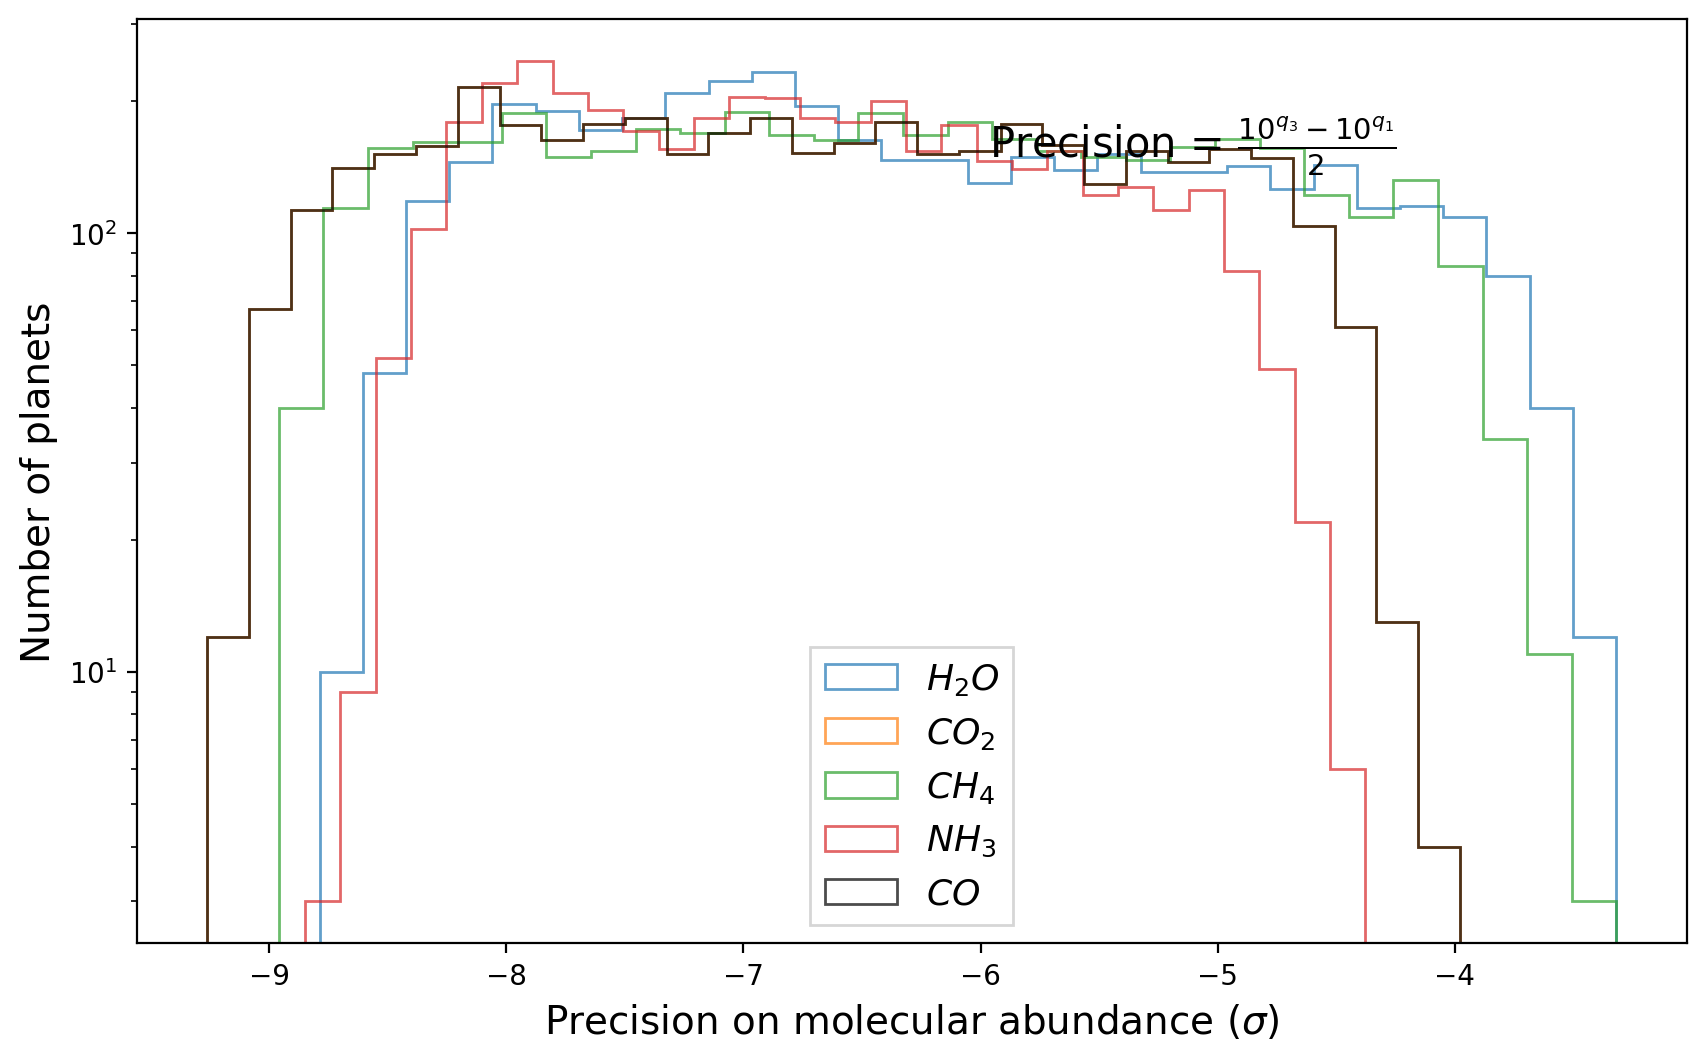

In [293]:
fig, ax = plt.subplots(figsize=(10, 6))

print(jovians[jovians["log H2O precision"]<1.5].shape[0])
print(jovians[jovians["log H2O precision"].notna()].shape[0])

ax.hist(jovians[jovians["log H2O precision"]<1.5]["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"$H_2O$")
ax.hist(jovians[jovians["log CO2 precision"]<1.5]["log CO2 precision"], bins=30, histtype='step', alpha=0.7, label=r"$CO_2$")
ax.hist(jovians[jovians["log CH4 precision"]<1.5]["log CH4 precision"], bins=30, histtype='step', alpha=0.7, label=r"$CH_4$")
ax.hist(jovians[jovians["log NH3 precision"]<1.5]["log NH3 precision"], bins=30, histtype='step', alpha=0.7, label=r"$NH_3$")
ax.hist(jovians[jovians["log CO2 precision"]<1.5]["log CO2 precision"], bins=30, histtype='step', alpha=0.7, label=r"$CO$", color='k')

ax.legend(fontsize=13, fancybox=False)

ax.set_yscale('log')

ax.text(0.55, 0.85, r"Precision = $\frac{10^{q_3} - 10^{q_1}}{2}$", transform=ax.transAxes, fontsize=15)

ax.set_xlabel(r"Precision on molecular abundance ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)

plt.show()

In [220]:
import numpy as np
import pandas as pd
from scipy import stats

def calculate_metrics_with_bootstrap(
    df, column, lt_condition=None, gt_condition=None, n_bootstrap=1000, confidence_level=0.95
):
    """
    Calculate metrics with optional filtering and bootstrap confidence intervals.
    
    Parameters:
    - df: DataFrame containing the data.
    - column: The column to calculate metrics for.
    - lt_condition: If provided, filter rows where column < lt_condition.
    - gt_condition: If provided, filter rows where column > gt_condition.
    - n_bootstrap: Number of bootstrap samples for confidence intervals.
    - confidence_level: Confidence level for the intervals.

    Returns:
    - Dictionary of metrics including mean, median, and confidence intervals.
    """
    # Copy the DataFrame to avoid modifying the original
    precision_data = df[column].dropna().copy()
    
    # Apply filtering based on conditions
    if lt_condition is not None:
        precision_data = precision_data[precision_data < lt_condition]
    if gt_condition is not None:
        precision_data = precision_data[precision_data > gt_condition]
    
    # Check if data is valid after filtering
    if len(precision_data) == 0:
        return {
            "Expected Precision (Mean)": np.nan,
            "Median Precision": np.nan,
            "Median CI Lower": np.nan,
            "Median CI Upper": np.nan,
            "95% CI Lower (Mean)": np.nan,
            "95% CI Upper (Mean)": np.nan,
            "Standard Deviation": np.nan,
            "Targets considered": 0
        }
    
    # Basic statistics
    mean = precision_data.mean()
    median = precision_data.median()
    std_dev = precision_data.std()
    n = len(precision_data)
    
    # Standard error of the mean
    sem = std_dev / np.sqrt(n)
    
    # Confidence interval for the mean (assuming normality)
    z = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    ci_lower = mean - z * sem
    ci_upper = mean + z * sem
    
    # Bootstrap for median confidence interval
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(precision_data, size=n, replace=True)
        bootstrap_medians.append(np.median(sample))
    median_ci_lower = np.percentile(bootstrap_medians, (1 - confidence_level) / 2 * 100)
    median_ci_upper = np.percentile(bootstrap_medians, (1 + confidence_level) / 2 * 100)
    
    # Return the results as a dictionary
    return {
        "Expected Precision (Mean)": mean,
        "Standard Deviation": std_dev,
        "Median Precision": median,
        "Median Lower": median_ci_lower,
        "Median Upper": median_ci_upper,
        "Targets considered": len(precision_data)
    }

# Apply the function to precision columns
# Assuming `jovians` is a DataFrame with precision columns labeled appropriately
results = {
    col.split()[0]: calculate_metrics_with_bootstrap(jovians, col, lt_condition=1.5)
    for col in jovians.columns if ("precision" in col.lower() and "temperature" not in col.lower())
}

# Create a DataFrame to display the results
df_results = pd.DataFrame(results).T.reset_index()
df_results.rename(columns={"index": "Molecule"}, inplace=True)

# Display the resulting DataFrame with styling
# styled_df = df_results.style.format(precision=2).set_table_attributes('style="display:inline"')

# display as csv
df_results.to_csv("jovians_precision_metrics.csv", index=False)

df_results


,Molecule,Expected Precision (Mean),Standard Deviation,Median Precision,Median Lower,Median Upper,Targets considered
0,log,0.151237,0.224953,0.093132,0.091295,0.095859,1933.0


In [221]:
print("Percentage of NAN values for CO2:", jovians["log_CO2_q2"].isna().sum() / jovians.shape[0] * 100, "%")
print("Percentage of NAN values for CH4:", jovians["log_CH4_q2"].isna().sum() / jovians.shape[0] * 100, "%")
print("Percentage of NAN values for NH3:", jovians["log_NH3_q2"].isna().sum() / jovians.shape[0] * 100, "%")
print("Percentage of NAN values for H2O:", jovians["log_H2O_q2"].isna().sum() / jovians.shape[0] * 100, "%")
print("Percentage of NAN values for CO:", jovians["log_CO_q2"].isna().sum() / jovians.shape[0] * 100, "%")

Percentage of NAN values for CO2: 76.29253076078794 %
Percentage of NAN values for CH4: 76.29253076078794 %
Percentage of NAN values for NH3: 76.29253076078794 %
Percentage of NAN values for H2O: 76.29253076078794 %
Percentage of NAN values for CO: 76.29253076078794 %


In [180]:
def calculate_metrics_with_bootstrap(column, n_bootstrap=1000, confidence_level=0.95):
    # Drop NaN values to avoid issues
    precision_data = column.dropna()
    
    # Basic statistics
    mean = precision_data.mean()
    median = precision_data.median()
    std_dev = precision_data.std()
    n = len(precision_data)
    
    # Standard error of the mean
    sem = std_dev / np.sqrt(n)
    
    # Confidence interval for the mean (assuming normality)
    z = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    ci_lower = mean - z * sem
    ci_upper = mean + z * sem
    
    # Bootstrap for median confidence interval
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(precision_data, size=n, replace=True)
        bootstrap_medians.append(np.median(sample))
    median_ci_lower = np.percentile(bootstrap_medians, (1 - confidence_level) / 2 * 100)
    median_ci_upper = np.percentile(bootstrap_medians, (1 + confidence_level) / 2 * 100)
    
    # Return the results as a dictionary
    return {
        "Expected Precision (Mean)": mean,
        "95% CI Lower (Mean)": ci_lower,
        "95% CI Upper (Mean)": ci_upper,
        "Median Precision": median,
        "Median CI Lower": median_ci_lower,
        "Median CI Upper": median_ci_upper,
        "Standard Deviation": std_dev,
        "Targets considered": precision_data.shape[0]
    }

# Apply the function to precision columns
# Assuming `jovians` is a DataFrame with precision columns labeled appropriately
results = {
    col.split()[0]: calculate_metrics_with_bootstrap(jovians[col])
    for col in jovians.columns if "precision" in col.lower()
}

# Create a DataFrame to display the results
df_results = pd.DataFrame(results).T.reset_index()
df_results.rename(columns={"index": "Molecule"}, inplace=True)

# Display the resulting DataFrame
df_results.to_csv("jovians_precision_metrics.csv", index=False)
df_results.style.format(precision=2).set_table_attributes('style="display:inline"')

,Molecule,Expected Precision (Mean),95% CI Lower (Mean),95% CI Upper (Mean),Median Precision,Median CI Lower,Median CI Upper,Standard Deviation,Targets considered
0,log,1.08,1.05,1.10,1.60,1.56,1.63,0.90,4104.00
1,Temperature,19.13,18.70,19.55,16.46,16.00,16.95,13.83,4104.00


In [222]:
np.log10(10**jovians["log H2O precision"] * jovians["Observations"]**0.5)
jovians["Observations"]

0        49795.0
1           42.0
2            6.0
3           34.0
4            1.0
          ...   
17306       21.0
17307    73893.0
17308        4.0
17309       20.0
17310        7.0
Name: Observations, Length: 17311, dtype: float64

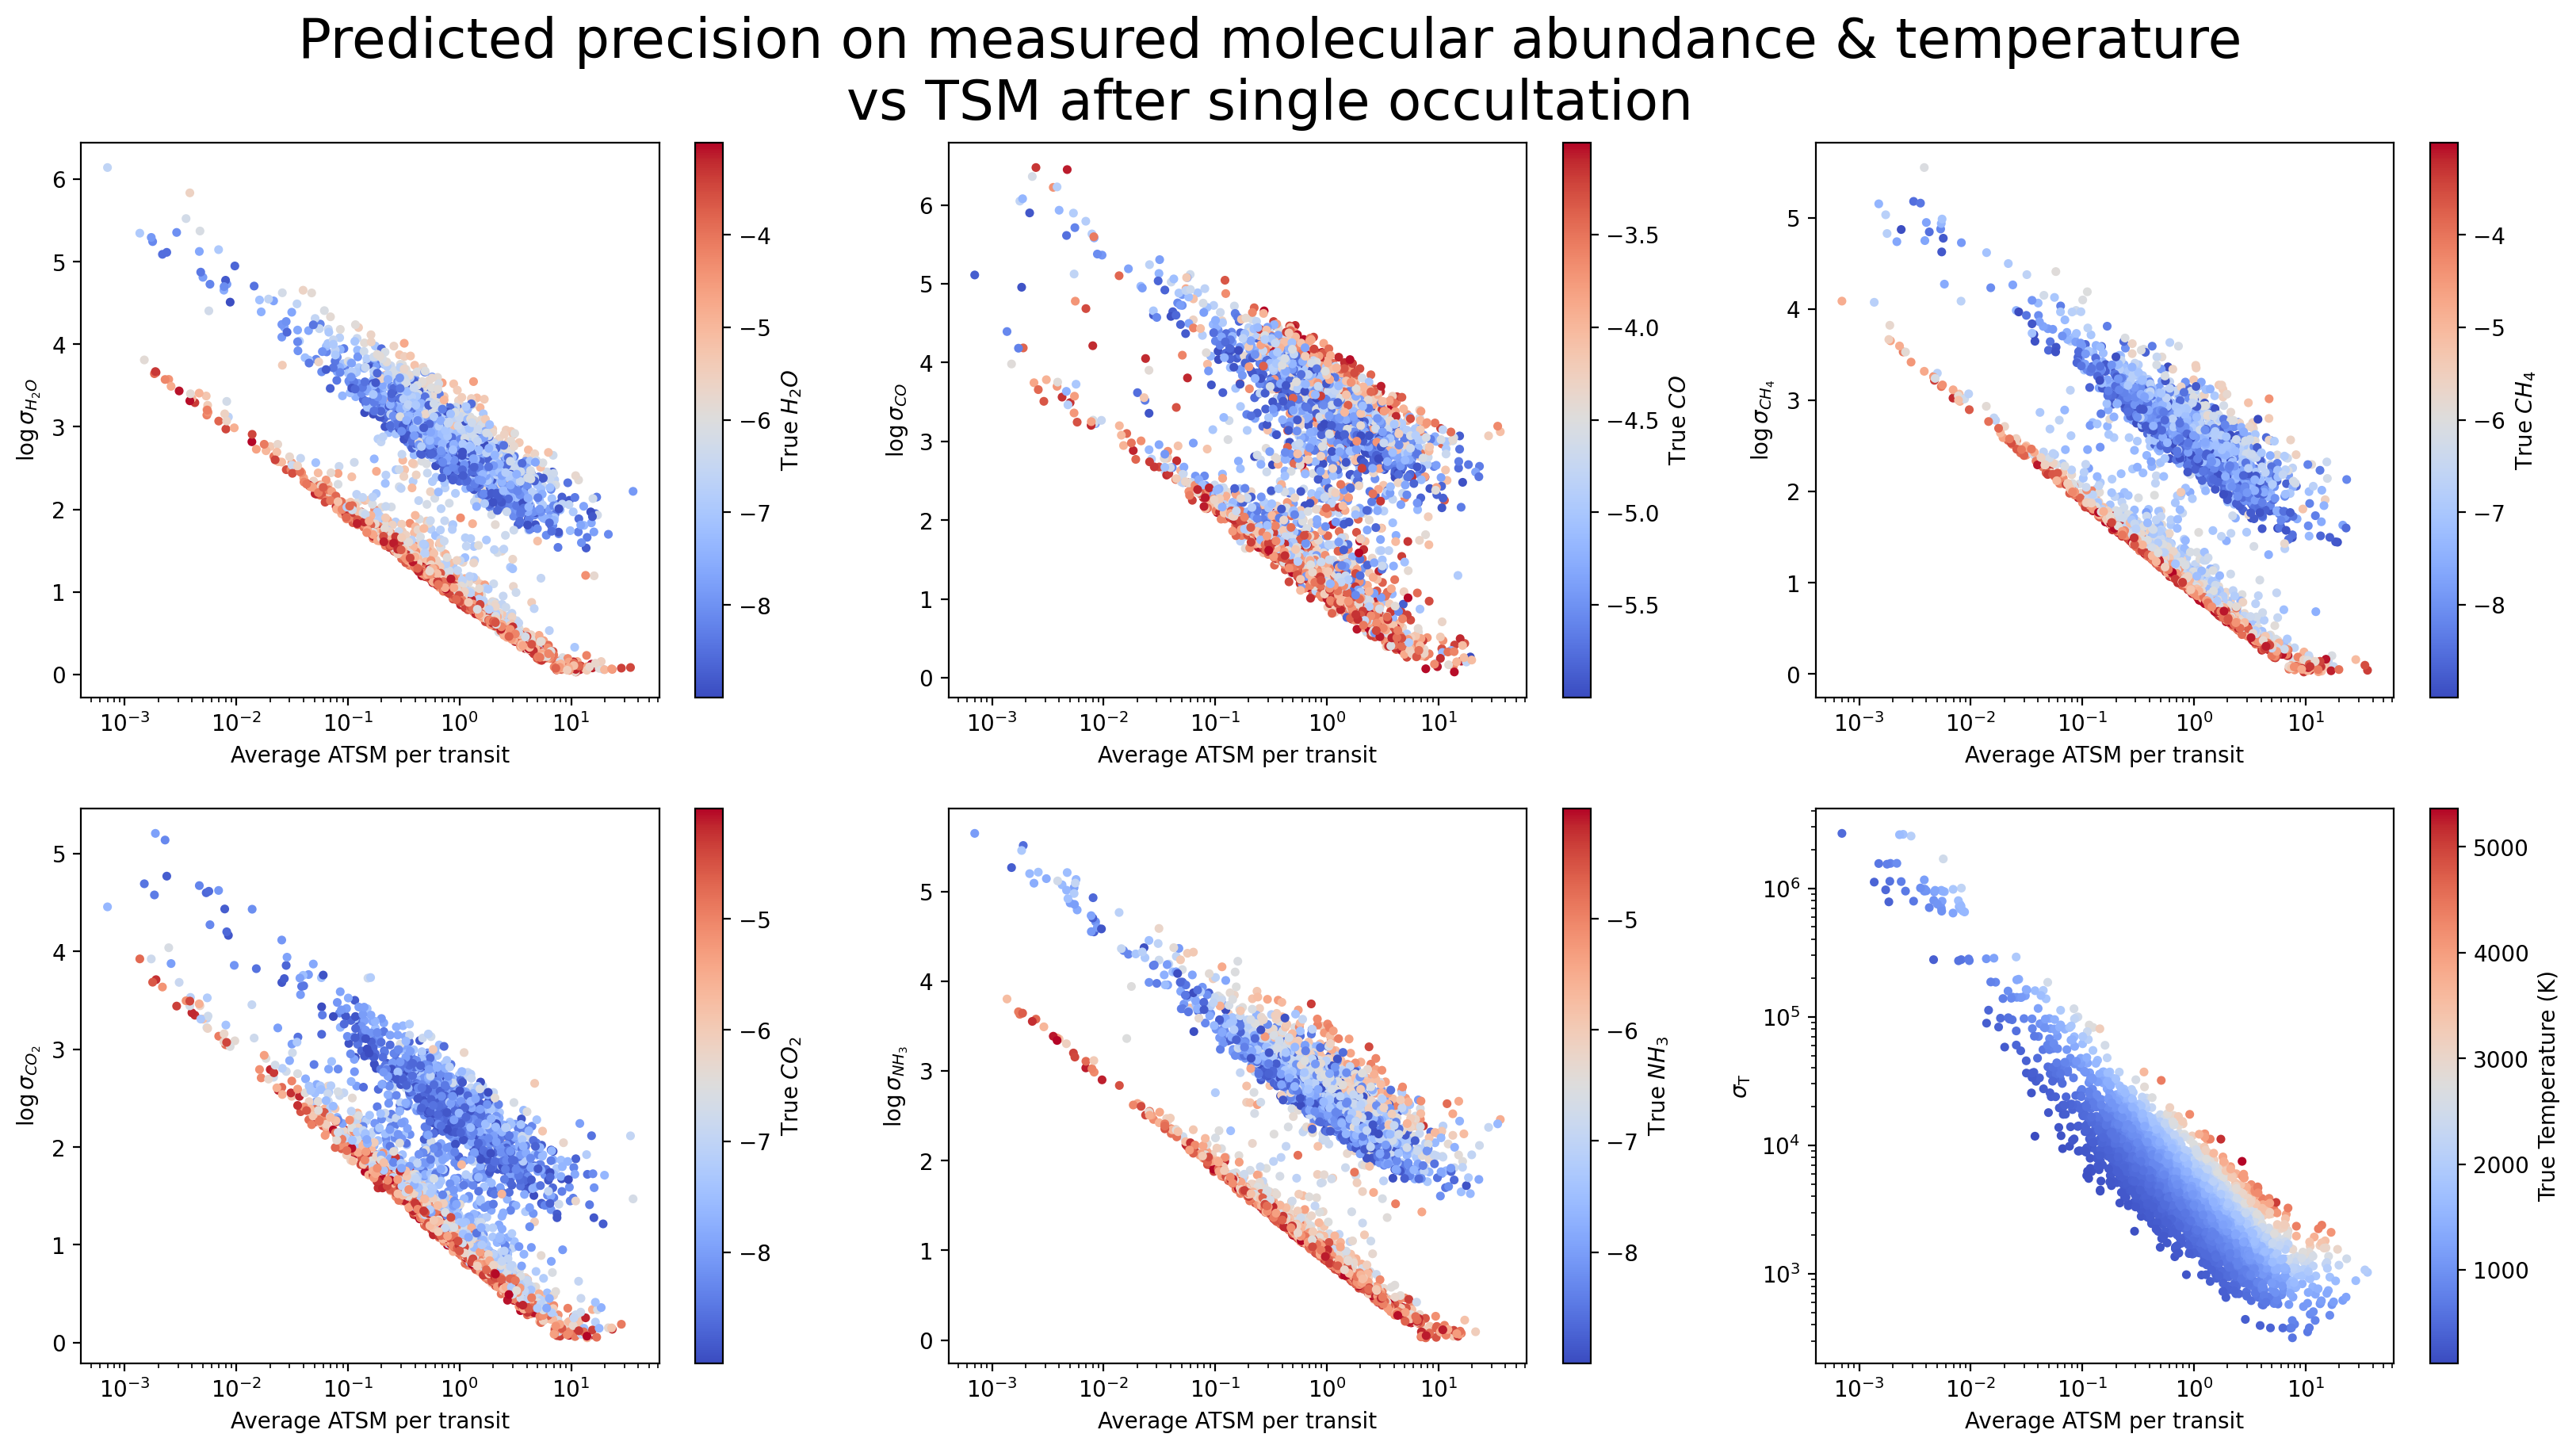

In [277]:
# plt.scatter(jovians["Average TSM"], jovians["log H2O precision"], marker='.')
# plt.scatter(jovians["Average TSM"], jovians["log CO2 precision"], marker='.')


jovians["Temperature precision"] = jovians["T_q3"] - jovians["T_q1"] / 2

# jovians["H2O precision single transit"] = np.log10(10**jovians["log H2O precision"] * jovians["Observations"]**0.5)
# jovians["CO precision single transit"] = np.log10(10**jovians["log CO2 precision"] * jovians["Observations"]**0.5)
# jovians["CH4 precision single transit"] = np.log10(10**jovians["log CH4 precision"] * jovians["Observations"]**0.5)
# jovians["CO2 precision single transit"] = np.log10(10**jovians["log CO2 precision"] * jovians["Observations"]**0.5)
# jovians["NH3 precision single transit"] = np.log10(10**jovians["log NH3 precision"] * jovians["Observations"]**0.5)
jovians["H2O precision single transit"] = jovians["log H2O precision"] + np.log10(jovians["Observations"])/2
jovians["CO precision single transit"] = jovians["log CO precision"] + np.log10(jovians["Observations"])/2
jovians["CH4 precision single transit"] = jovians["log CH4 precision"] + np.log10(jovians["Observations"])/2
jovians["CO2 precision single transit"] = jovians["log CO2 precision"] + np.log10(jovians["Observations"])/2
jovians["NH3 precision single transit"] = jovians["log NH3 precision"] + np.log10(jovians["Observations"])/2
jovians["Temperature precision single transit"] = jovians["Temperature precision"] * jovians["Observations"]**0.5

fig, ax = plt.subplots(2,3, figsize=(20, 10))

fig.suptitle("Predicted precision on measured molecular abundance & temperature\nvs TSM after single occultation", fontsize=25, y=0.96)

cax = ax[0,0].scatter(jovians["Average TSM one transit"], jovians["H2O precision single transit"], marker='.', c=jovians["log_H2O"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[0,0], label=r"True $H_2O$")
# ax[0,0].set_yscale("log")
ax[0,0].set_xscale("log")
ax[0,0].set_ylabel(r"$\log \sigma_{H_2O}$")
ax[0,0].set_xlabel("Average ATSM per transit")

cax = ax[0,1].scatter(jovians["Average TSM one transit"], jovians["CO precision single transit"], marker='.', c=jovians["log_CO"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[0,1], label=r"True $CO$")
# ax[0,1].set_yscale("log")
ax[0,1].set_xscale("log")
ax[0,1].set_ylabel(r"$\log \sigma_{CO}$")
ax[0,1].set_xlabel("Average ATSM per transit")

cax = ax[0,2].scatter(jovians["Average TSM one transit"], jovians["CH4 precision single transit"], marker='.', c=jovians["log_CH4"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[0,2], label=r"True $CH_4$")
# ax[0,2].set_yscale("log")
ax[0,2].set_xscale("log")
ax[0,2].set_ylabel(r"$\log \sigma_{CH_4}$")
ax[0,2].set_xlabel("Average ATSM per transit")

cax = ax[1,0].scatter(jovians["Average TSM one transit"], jovians["CO2 precision single transit"], marker='.', c=jovians["log_CO2"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[1,0], label=r"True $CO_2$")
# ax[1,0].set_yscale("log")
ax[1,0].set_xscale("log")
ax[1,0].set_ylabel(r"$\log \sigma_{CO_2}$")
ax[1,0].set_xlabel("Average ATSM per transit")

cax = ax[1,1].scatter(jovians["Average TSM one transit"], jovians["NH3 precision single transit"], marker='.', c=jovians["log_NH3"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[1,1], label=r"True $NH_3$")
# ax[1,1].set_yscale("log")
ax[1,1].set_xscale("log")
ax[1,1].set_ylabel(r"$\log \sigma_{NH_3}$")
ax[1,1].set_xlabel("Average ATSM per transit")

cax = ax[1,2].scatter(jovians["Average TSM one transit"], jovians["Temperature precision single transit"], marker='.', c=jovians["T_q2"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[1,2], label=r"True Temperature (K)")
ax[1,2].set_yscale("log")
ax[1,2].set_xscale("log")
ax[1,2].set_ylabel(r"$\sigma_\text{T}$")
ax[1,2].set_xlabel("Average ATSM per transit")


plt.show()

In [282]:
# fig, ax = plt.subplots(2,3, figsize=(20, 10))

# fig.suptitle("Predicted precision on measured molecular abundance & temperature\nvs TSM after single occultation", fontsize=25, y=0.96)

# cax = ax[0,0].scatter(jovians["Average TSM"], jovians["log H2O precision"] - 1, marker='.', c=jovians["log_H2O"], cmap="coolwarm")
# plt.colorbar(cax, ax=ax[0,0], label=r"log($H_2O$)")
# ax[0,0].set_xscale("log")
# ax[0,0].set_ylabel(r"$H_2O$ precision per transit [$\sigma - \mu$]")
# ax[0,0].set_xlabel("Average TSM per transit")

# cax = ax[0,1].scatter(jovians["Average TSM one transit"], jovians["CO precision single transit"] - 1, marker='.', c=jovians["log_CO"], cmap="coolwarm")
# plt.colorbar(cax, ax=ax[0,1], label=r"log($CO$)")
# ax[0,1].set_xscale("log")
# ax[0,1].set_ylabel(r"$CO$ precision per transit [$\sigma - \mu$]")
# ax[0,1].set_xlabel("Average TSM per transit")

# cax = ax[0,2].scatter(jovians["Average TSM one transit"], jovians["CH4 precision single transit"] - jovians["log_CH4_q2"], marker='.', c=jovians["log_CH4"], cmap="coolwarm")
# plt.colorbar(cax, ax=ax[0,2], label=r"log($CH_4$)")
# # ax[0,2].set_yscale("log")
# ax[0,2].set_xscale("log")
# ax[0,2].set_ylabel(r"$CH_4$ precision per transit [$\sigma - \mu$]")
# ax[0,2].set_xlabel("Average TSM per transit")

# cax = ax[1,0].scatter(jovians["Average TSM one transit"], jovians["CO2 precision single transit"] - jovians["log_CO2_q2"], marker='.', c=jovians["log_CO2"], cmap="coolwarm")
# plt.colorbar(cax, ax=ax[1,0], label=r"log($CO_2$)")
# # ax[1,0].set_yscale("log")
# ax[1,0].set_xscale("log")
# ax[1,0].set_ylabel(r"$CO_2$ precision [$\sigma - \mu$]")
# ax[1,0].set_xlabel("Average TSM per transit")

# cax = ax[1,1].scatter(jovians["Average TSM one transit"], jovians["NH3 precision single transit"] - jovians["log_NH3_q2"], marker='.', c=jovians["log_NH3"], cmap="coolwarm")
# plt.colorbar(cax, ax=ax[1,1], label=r"log($NH_3$)")
# # ax[1,1].set_yscale("log")
# ax[1,1].set_xscale("log")
# ax[1,1].set_ylabel(r"$NH_3$ precision per transit [$\sigma - \mu$]")
# ax[1,1].set_xlabel("Average TSM per transit")

# cax = ax[1,2].scatter(jovians["Average TSM one transit"], jovians["Temperature precision single transit"]/jovians["T_q2"], marker='.', c=jovians["Dayside Emitting Temperature [K]"], cmap="coolwarm")
# plt.colorbar(cax, ax=ax[1,2], label=r"Temperature (K)")
# ax[1,2].set_yscale("log")
# ax[1,2].set_xscale("log")
# ax[1,2].set_ylabel(r"Temperature precision per transit [$\sigma/\mu$]")
# ax[1,2].set_xlabel("Average TSM per transit")


# plt.show()

In [288]:

watery_jovians = jovians[jovians["log_H2O"] > -5]
watery_longP_jovians = watery_jovians[(watery_jovians["planet_orbital_period"] > 50) & (watery_jovians["planet_orbital_period"] < 200)]
watery_medP_jovians = watery_jovians[(watery_jovians["planet_orbital_period"] > 5) & (watery_jovians["planet_orbital_period"] < 50)]
watery_shortP_jovians = watery_jovians[watery_jovians["planet_orbital_period"] < 5]
watery_verylongP_jovians = watery_jovians[watery_jovians["planet_orbital_period"] > 200]

dry_jovians = jovians[jovians["log_H2O"] < -7]
dry_longP_jovians = dry_jovians[(dry_jovians["planet_orbital_period"] > 50) & (dry_jovians["planet_orbital_period"] < 200)]
dry_medP_jovians = dry_jovians[(dry_jovians["planet_orbital_period"] > 5) & (dry_jovians["planet_orbital_period"] < 50)]
dry_shortP_jovians = dry_jovians[dry_jovians["planet_orbital_period"] < 5]
dry_verylongP_jovians = dry_jovians[dry_jovians["planet_orbital_period"] > 200]

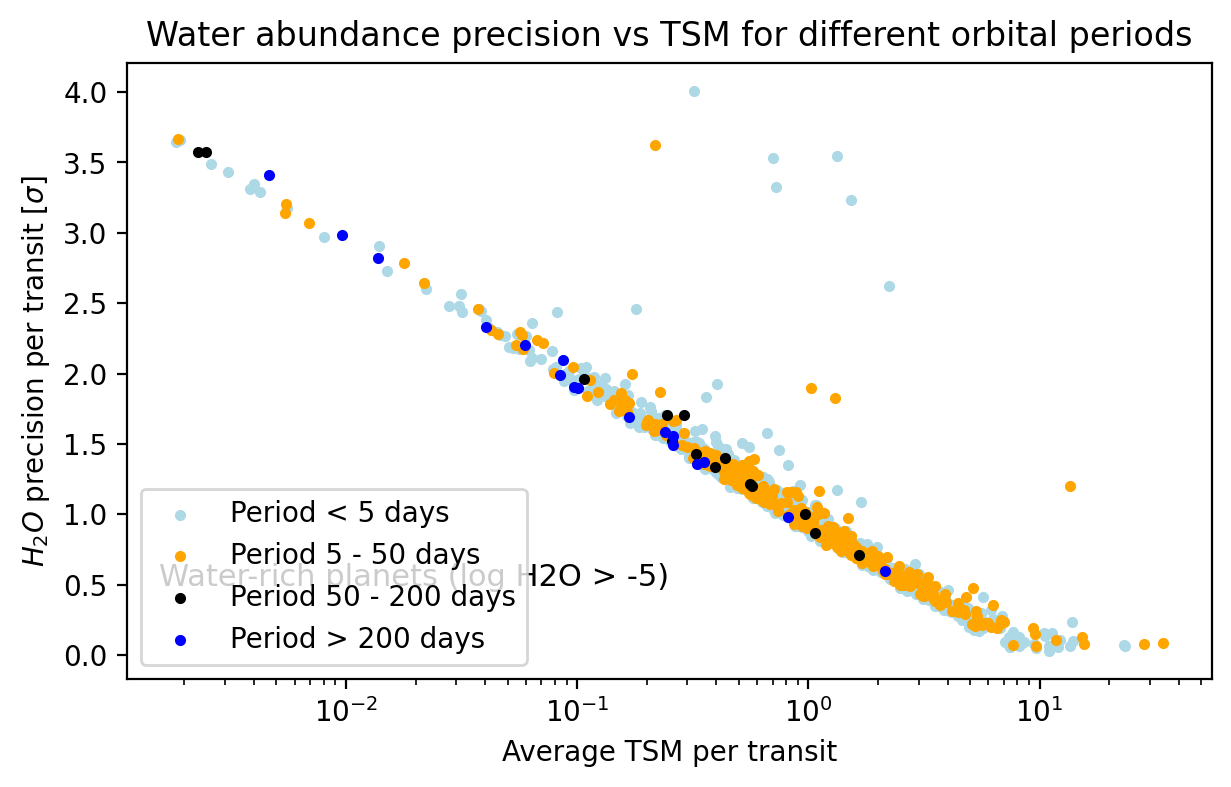

In [289]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(watery_shortP_jovians["Average TSM one transit"], watery_shortP_jovians["H2O precision single transit"], marker='.', c="lightblue", label="Period < 5 days")
ax.scatter(watery_medP_jovians["Average TSM one transit"], watery_medP_jovians["H2O precision single transit"], marker='.', c="orange", label="Period 5 - 50 days")
ax.scatter(watery_longP_jovians["Average TSM one transit"], watery_longP_jovians["H2O precision single transit"], marker='.', c='black', label="Period 50 - 200 days")
ax.scatter(watery_verylongP_jovians["Average TSM one transit"], watery_verylongP_jovians["H2O precision single transit"], marker='.', c='blue', label="Period > 200 days")
# ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
ax.set_ylabel(r"$H_2O$ precision per transit [$\sigma$]")
ax.set_xlabel("Average TSM per transit")
ax.set_title("Water abundance precision vs TSM for different orbital periods")

ax.text(0.03, 0.15, "Water-rich planets (log H2O > -5)", transform=ax.transAxes, fontsize=11)

plt.show()

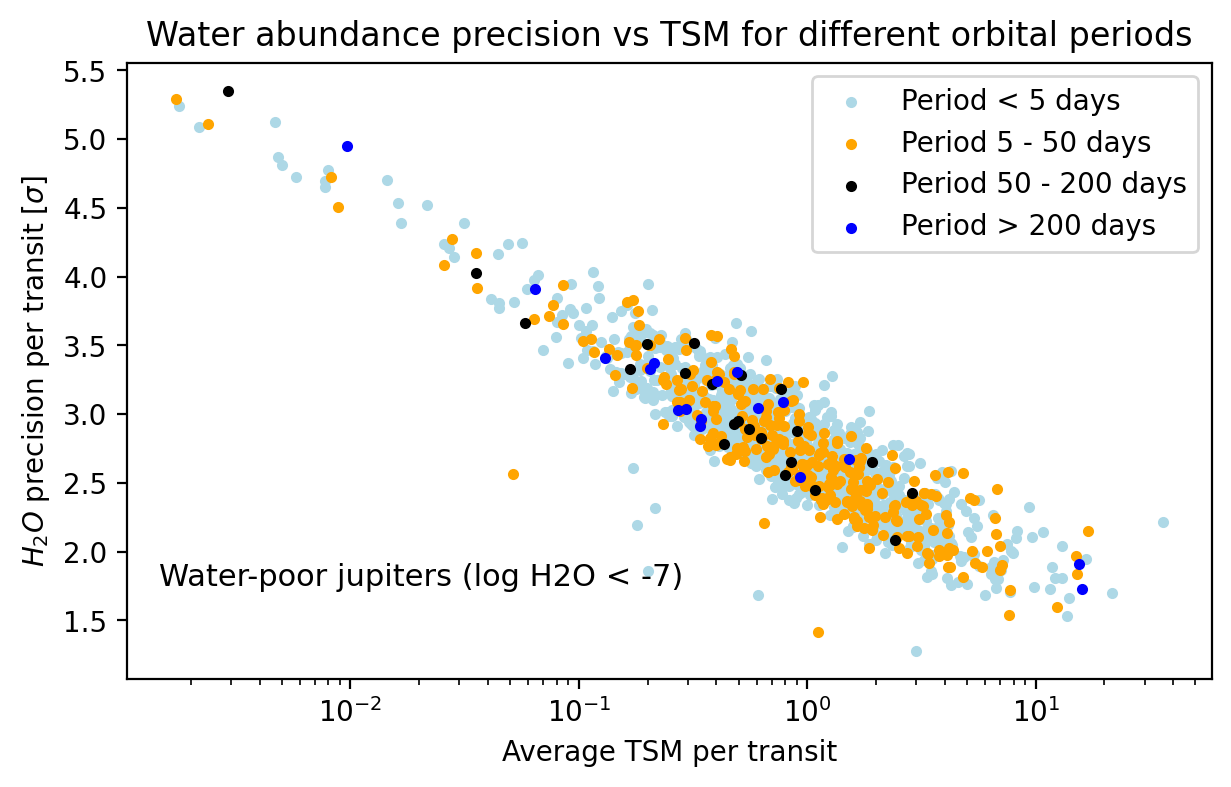

In [290]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(dry_shortP_jovians["Average TSM one transit"], dry_shortP_jovians["H2O precision single transit"], marker='.', c="lightblue", label="Period < 5 days")
ax.scatter(dry_medP_jovians["Average TSM one transit"], dry_medP_jovians["H2O precision single transit"], marker='.', c="orange", label="Period 5 - 50 days")
ax.scatter(dry_longP_jovians["Average TSM one transit"], dry_longP_jovians["H2O precision single transit"], marker='.', c='black', label="Period 50 - 200 days")
ax.scatter(dry_verylongP_jovians["Average TSM one transit"], dry_verylongP_jovians["H2O precision single transit"], marker='.', c='blue', label="Period > 200 days")
# ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(loc="upper right")
ax.set_ylabel(r"$H_2O$ precision per transit [$\sigma$]")
ax.set_xlabel("Average TSM per transit")
ax.set_title("Water abundance precision vs TSM for different orbital periods")

ax.text(0.03, 0.15, "Water-poor jupiters (log H2O < -7)", transform=ax.transAxes, fontsize=11)

plt.show()

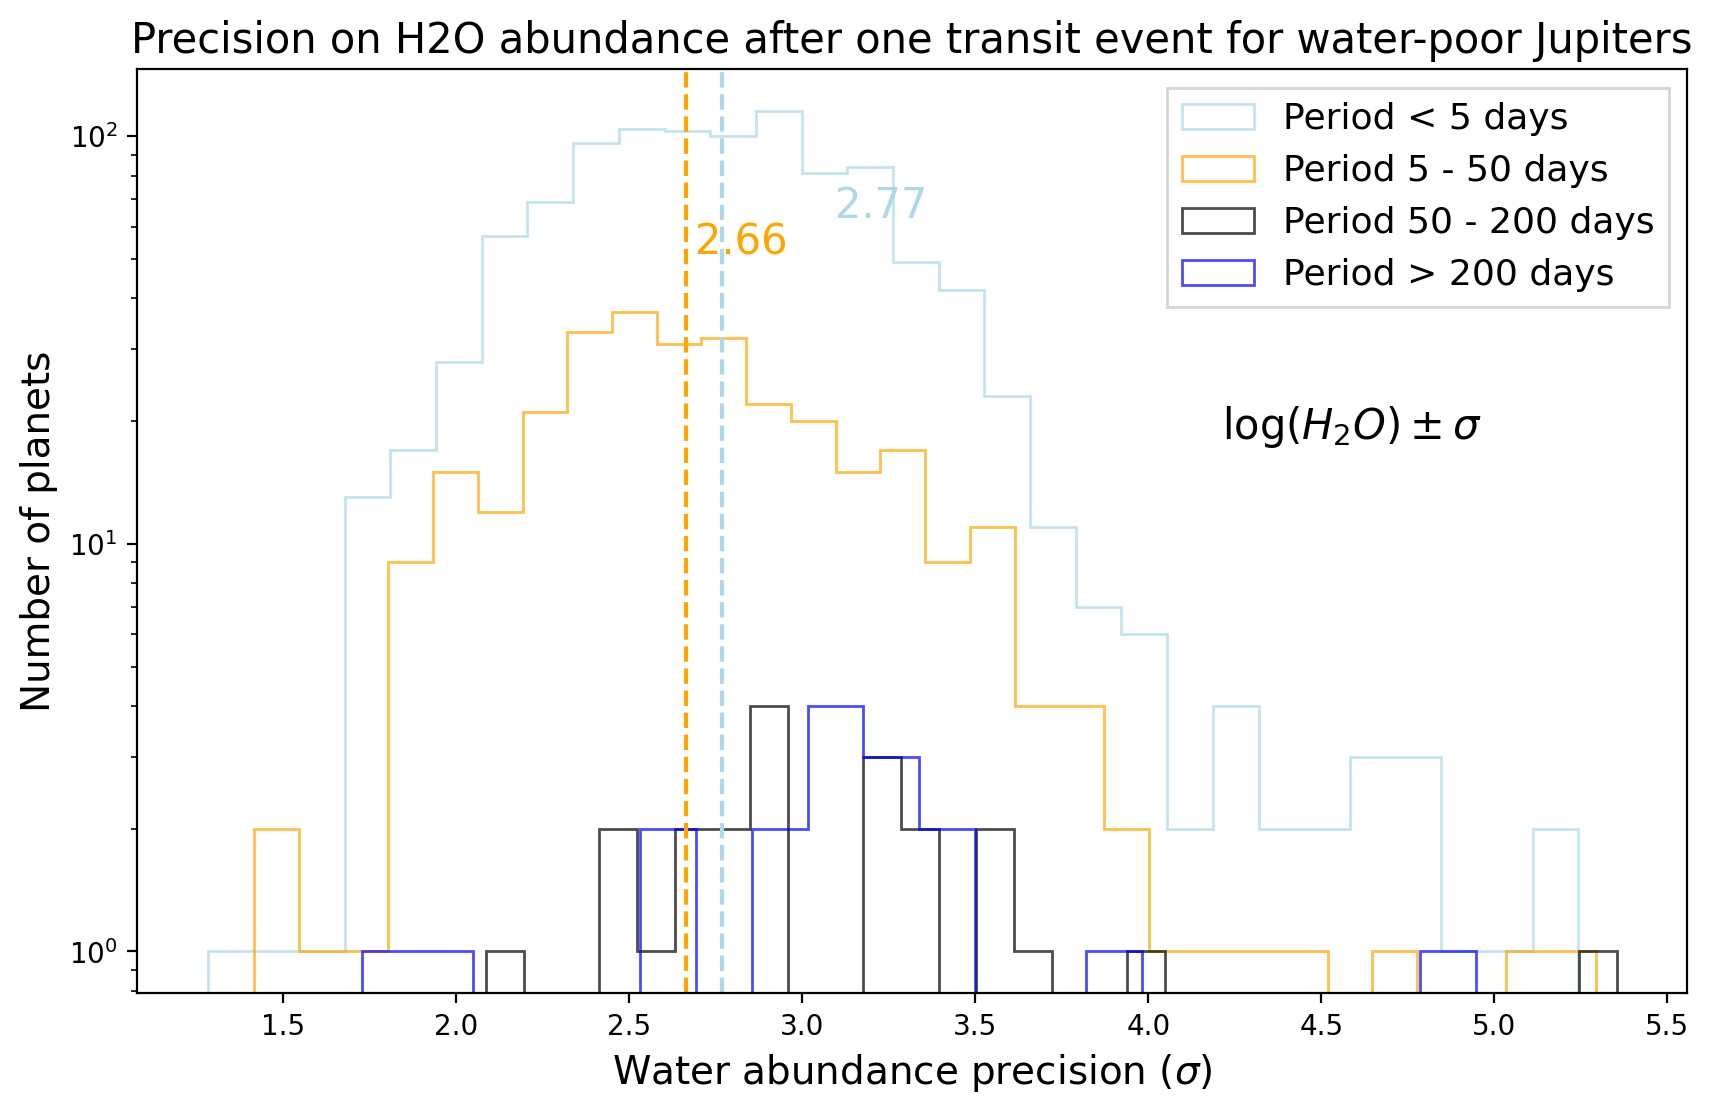

In [291]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(dry_shortP_jovians["H2O precision single transit"], bins=30, histtype='step', alpha=0.7, label=r"Period < 5 days", color="lightblue")
ax.hist(dry_medP_jovians["H2O precision single transit"], bins=30, histtype='step', alpha=0.7, label=r"Period 5 - 50 days", color="orange")
ax.hist(dry_longP_jovians["H2O precision single transit"], bins=30, histtype='step', alpha=0.7, label=r"Period 50 - 200 days", color='black')
ax.hist(dry_verylongP_jovians["H2O precision single transit"], bins=20, histtype='step', alpha=0.7, label=r"Period > 200 days", color='blue')

shortPmed = dry_shortP_jovians["H2O precision single transit"].median()
ax.axvline(shortPmed, color='lightblue', linestyle='--')
ax.text(0.45, 0.84, f"{shortPmed:.3}", transform=ax.transAxes, fontsize=15, color='lightblue')

medPmed = dry_medP_jovians["H2O precision single transit"].median()
ax.axvline(medPmed, color='orange', linestyle='--')
ax.text(0.36, 0.8, f"{medPmed:.3}", transform=ax.transAxes, fontsize=15, color='orange')

ax.set_yscale('log')

ax.set_title("Precision on H2O abundance after one transit event for water-poor Jupiters", fontsize=15)

ax.set_xlabel(r"Water abundance precision ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)

ax.legend(fontsize=13, fancybox=False)

ax.text(0.7, 0.6, r"$\log(H_2O) \pm \sigma$", transform=ax.transAxes, fontsize=15)

plt.show()

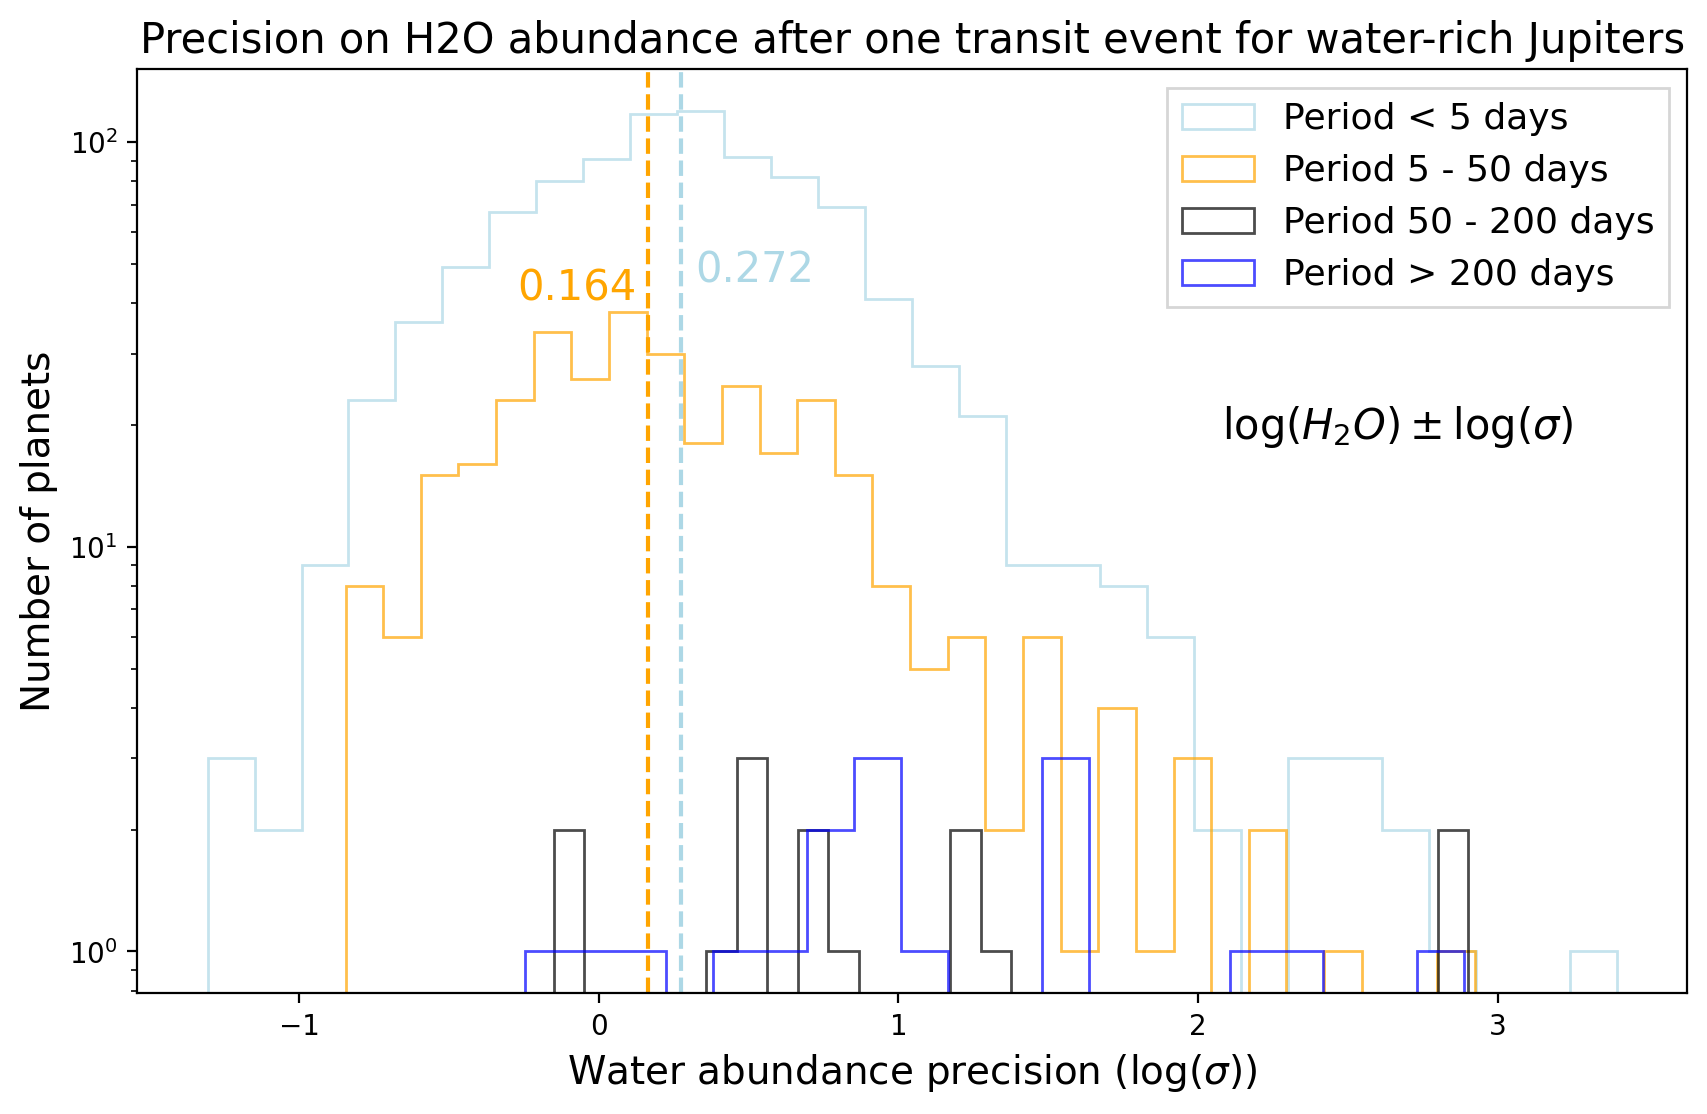

In [174]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(watery_shortP_jovians["H2O precision single transit"], bins=30, histtype='step', alpha=0.7, label=r"Period < 5 days", color="lightblue")
ax.hist(watery_medP_jovians["H2O precision single transit"], bins=30, histtype='step', alpha=0.7, label=r"Period 5 - 50 days", color="orange")
ax.hist(watery_longP_jovians["H2O precision single transit"], bins=30, histtype='step', alpha=0.7, label=r"Period 50 - 200 days", color='black')
ax.hist(watery_verylongP_jovians["H2O precision single transit"], bins=20, histtype='step', alpha=0.7, label=r"Period > 200 days", color='blue')

shortPmed = watery_shortP_jovians["H2O precision single transit"].median()
ax.axvline(shortPmed, color='lightblue', linestyle='--')
ax.text(0.36, 0.77, f"{shortPmed:.3}", transform=ax.transAxes, fontsize=15, color='lightblue')

medPmed = watery_medP_jovians["H2O precision single transit"].median()
ax.axvline(medPmed, color='orange', linestyle='--')
ax.text(0.245, 0.75, f"{medPmed:.3}", transform=ax.transAxes, fontsize=15, color='orange')

ax.set_yscale('log')

ax.set_title("Precision on H2O abundance after one transit event for water-rich Jupiters", fontsize=15)

ax.set_xlabel(r"Water abundance precision ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)

ax.legend(fontsize=13, fancybox=False)

ax.text(0.7, 0.6, r"$\log(H_2O) \pm \sigma$", transform=ax.transAxes, fontsize=15)

plt.show()

In [213]:
watery_verylongP_jovians[watery_verylongP_jovians["H2O precision single transit"] == watery_verylongP_jovians["H2O precision single transit"].min()]["log H2O precision"]

10623   -0.766091
Name: log H2O precision, dtype: float64

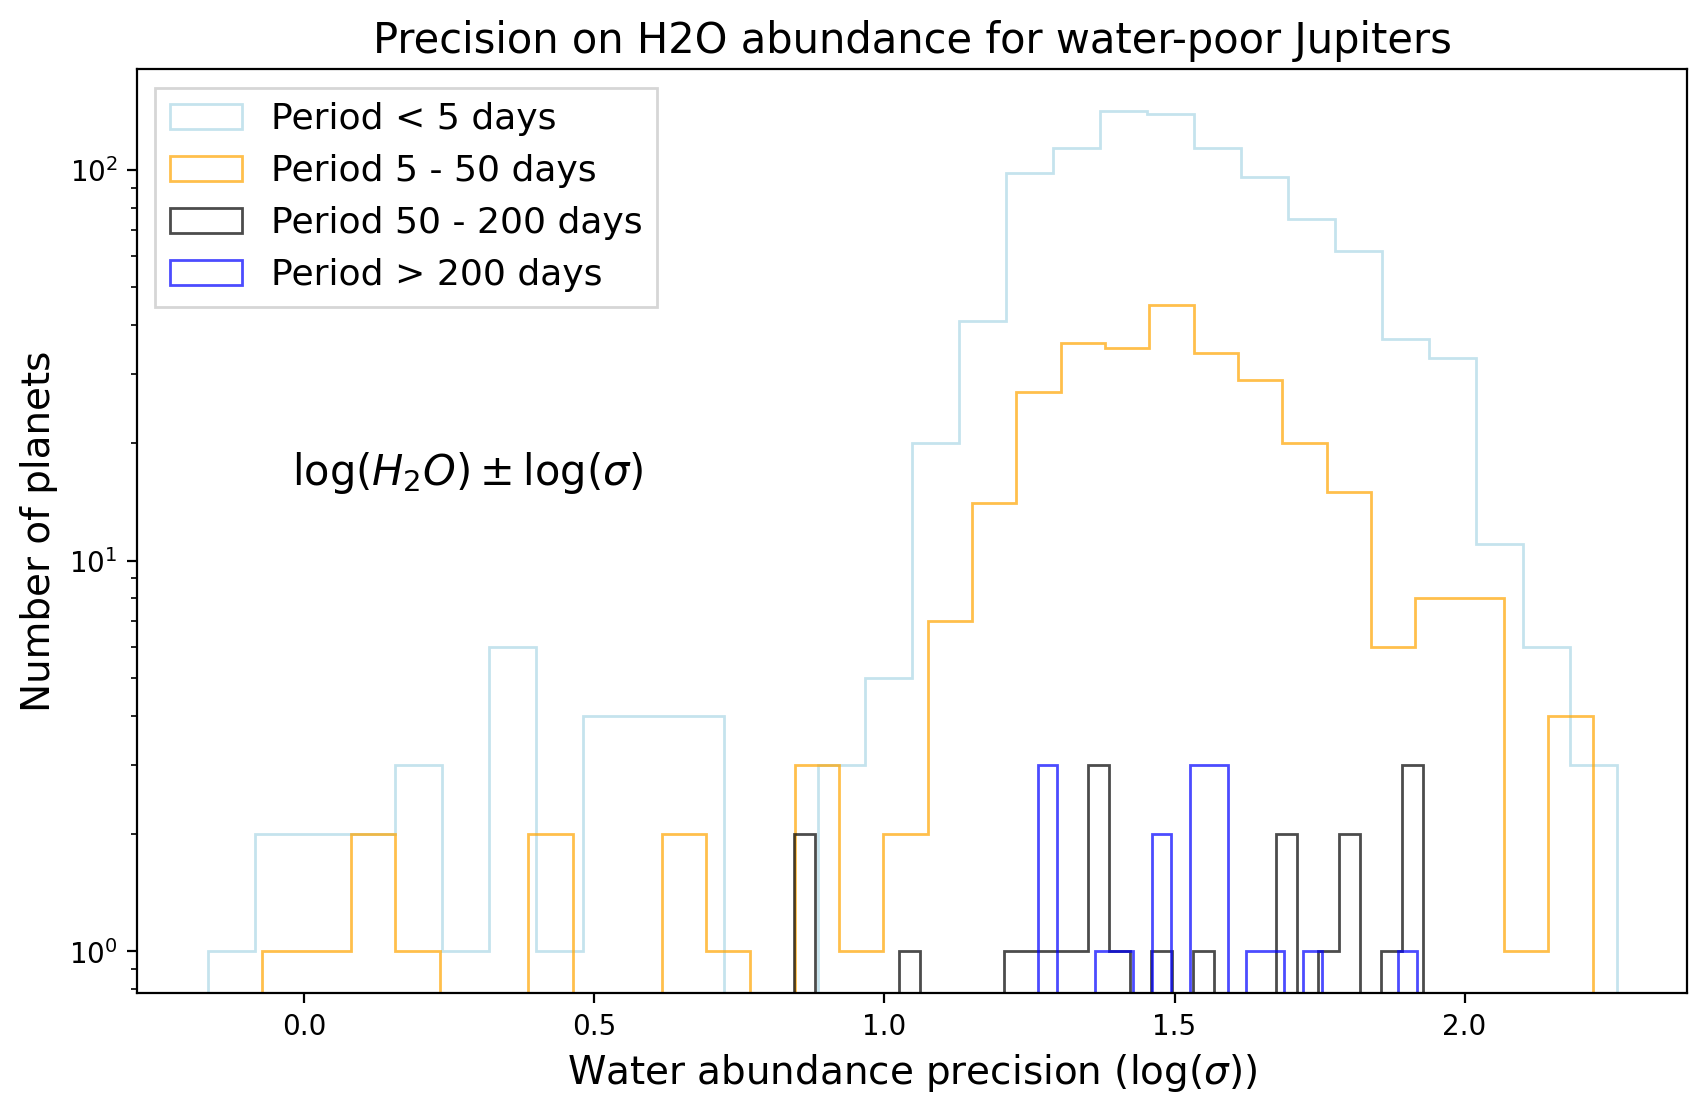

In [204]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(dry_shortP_jovians["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"Period < 5 days", color="lightblue")
ax.hist(dry_medP_jovians["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"Period 5 - 50 days", color="orange")
ax.hist(dry_longP_jovians["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"Period 50 - 200 days", color='black')
ax.hist(dry_verylongP_jovians["log H2O precision"], bins=20, histtype='step', alpha=0.7, label=r"Period > 200 days", color='blue')

ax.set_yscale('log')

ax.set_title("Precision on H2O abundance for water-poor Jupiters", fontsize=15)

ax.set_xlabel(r"Water abundance precision ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)

ax.legend(fontsize=13, fancybox=False)

ax.text(0.1, 0.55, r"$\log(H_2O) \pm \sigma$", transform=ax.transAxes, fontsize=15)

plt.show()

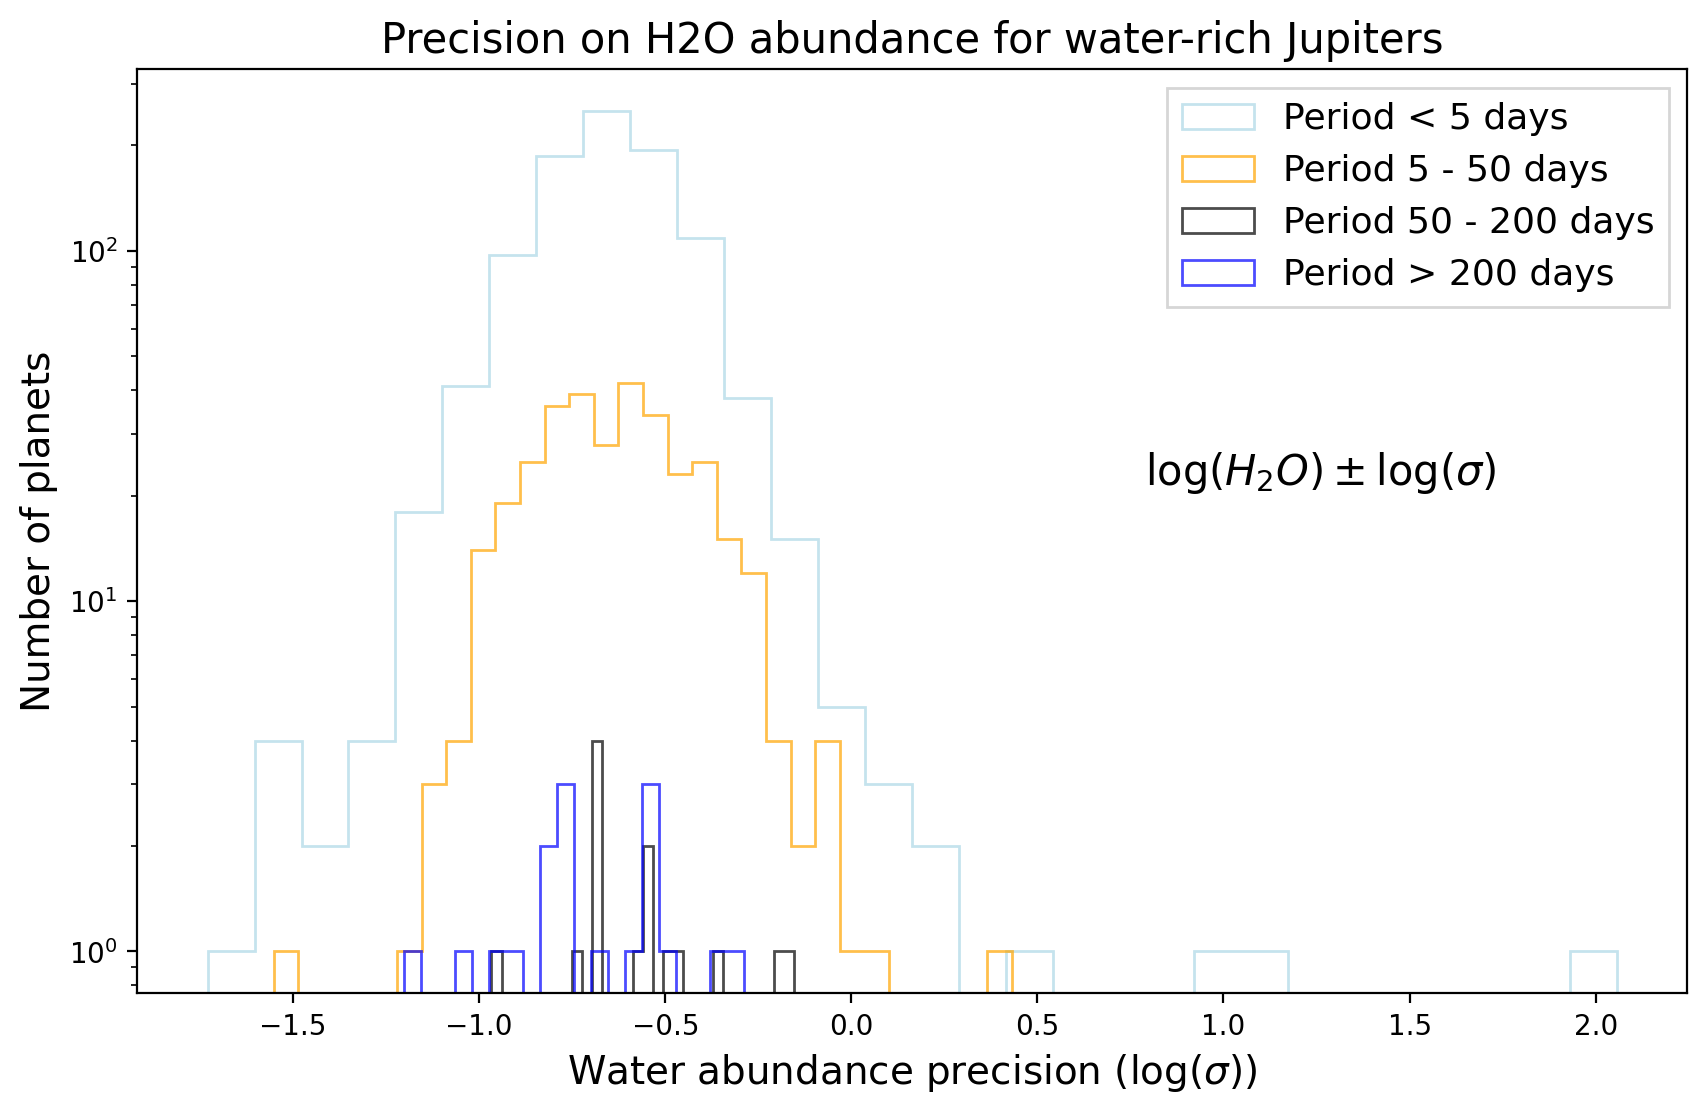

In [173]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(watery_shortP_jovians["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"Period < 5 days", color="lightblue")
ax.hist(watery_medP_jovians["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"Period 5 - 50 days", color="orange")
ax.hist(watery_longP_jovians["log H2O precision"], bins=30, histtype='step', alpha=0.7, label=r"Period 50 - 200 days", color='black')
ax.hist(watery_verylongP_jovians["log H2O precision"], bins=20, histtype='step', alpha=0.7, label=r"Period > 200 days", color='blue')

ax.set_yscale('log')

ax.set_title("Precision on H2O abundance for water-rich Jupiters", fontsize=15)

ax.set_xlabel(r"Water abundance precision ($\sigma$)", fontsize=14)
ax.set_ylabel("Number of planets", fontsize=14)

ax.legend(fontsize=13, fancybox=False)

ax.text(0.65, 0.55, r"$\log(H_2O) \pm \sigma$", transform=ax.transAxes, fontsize=15)

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.set_title("Predicted precision on measured molecular abundance & temperature\nvs TSM after single occultation", fontsize=15)

cax = ax.scatter(jovians["Average TSM one transit"], jovians["H2O precision single transit"], marker='.', c=jovians["log_H2O"], cmap="coolwarm")
plt.colorbar(cax, ax=ax, label=r"log($H_2O$)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel(r"$H_2O$ precision per transit [$\log(\sigma$)]")
ax.set_xlabel("Average TSM per transit")



plt.show()

In [25]:
print(jovians[(jovians["Planet Radius [Rjup]"]<0.6) & (jovians["Dayside Emitting Temperature [K]"]<500)].iloc[0]["planet_ID"])
print(jovians[(jovians["Planet Radius [Rjup]"]<0.6) & (jovians["Dayside Emitting Temperature [K]"]>1000)].iloc[0]["planet_ID"])
print(jovians[(jovians["Planet Radius [Rjup]"] == 1) & (jovians["Dayside Emitting Temperature [K]"]<500)].iloc[0]["planet_ID"])
print(jovians[(jovians["Planet Radius [Rjup]"] == 1) & (jovians["Dayside Emitting Temperature [K]"]>1000)].iloc[0]["planet_ID"])

planet_ID    8854.0
planet_ID    8854.0
planet_ID    8878.0
Name: 8854, dtype: float64
planet_ID    320.0
planet_ID    320.0
planet_ID    322.0
Name: 320, dtype: float64
planet_ID    15167.0
planet_ID    15167.0
planet_ID    15197.0
Name: 15167, dtype: float64
planet_ID    2606.0
planet_ID    2606.0
planet_ID    2614.0
Name: 2606, dtype: float64


In [97]:
Ariel.target_list_name = "ML_list_jovians"
Ariel.target_list = jovians
Ariel.target_list_changed = True


{'Ariel': {}}

In [102]:
Ariel.instruments = openInstruments(telescope="Ariel", target_list=Ariel.getTargetList()[0])

KeyError: 'ML_list_jovians'

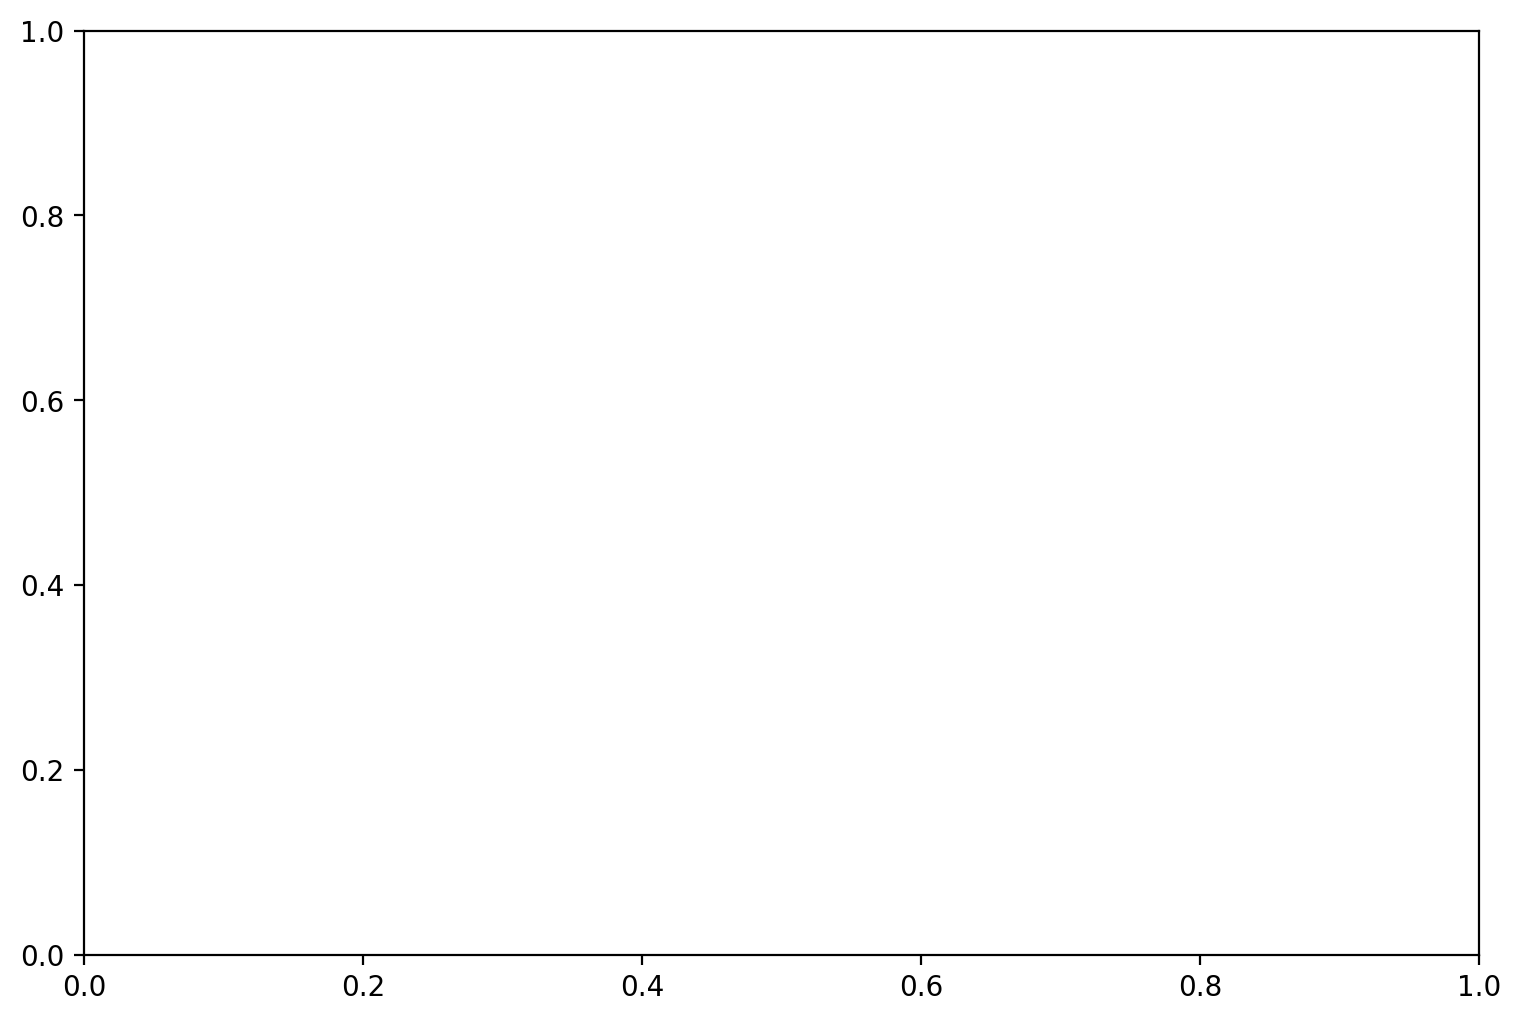

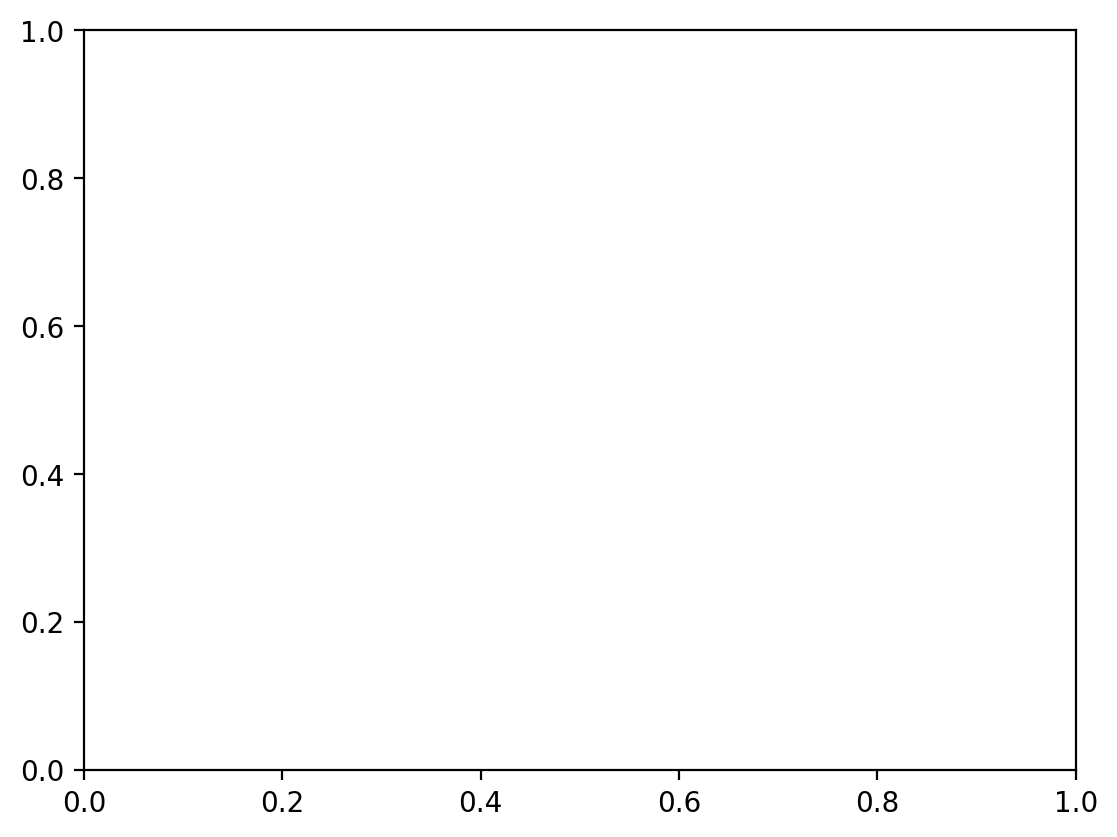

In [95]:
spec_instr_t2 = Ariel.getTieredInstruments('tier 2')[0][3:]

fig, ax = plt.subplots(figsize=(9,6))
Ariel.plotSensitivityRange()
Ariel.plotParamProfile(8854.0, spec_instr_t2, "TSM")

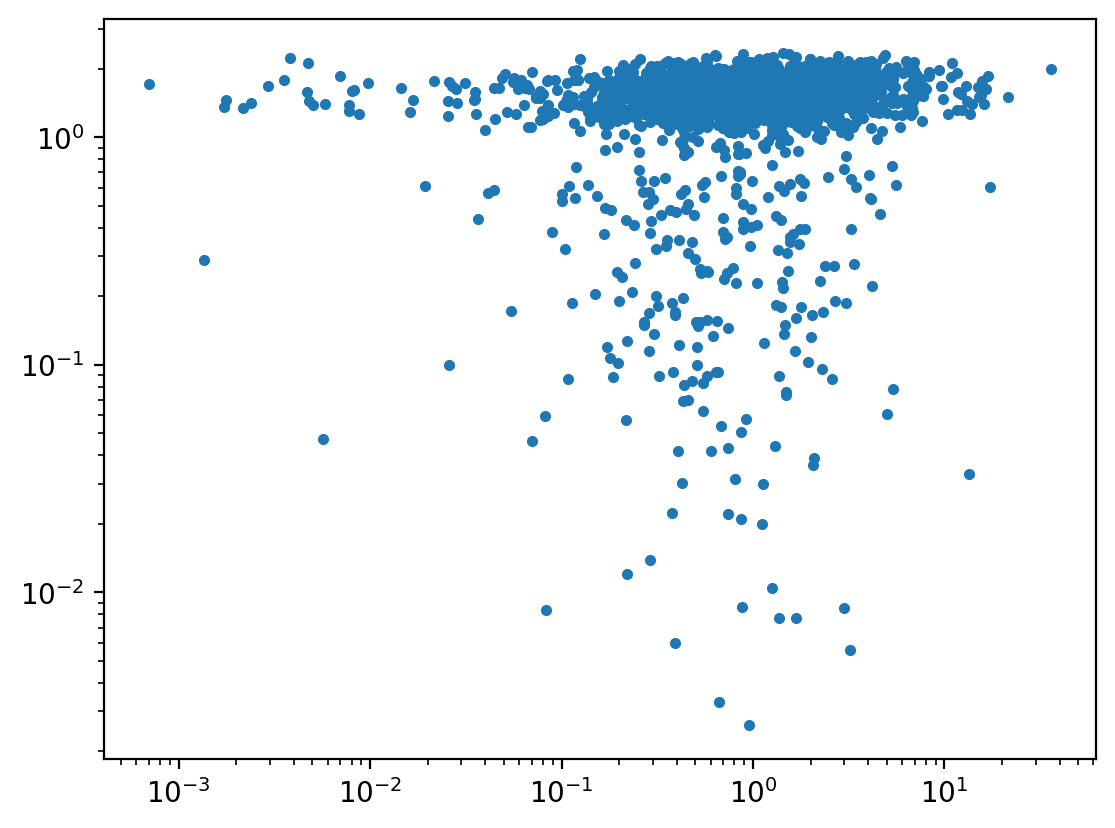

In [28]:
plt.scatter(jovians["Average TSM one transit"], jovians["log H2O precision"], marker='.')
plt.yscale("log")
plt.xscale("log")

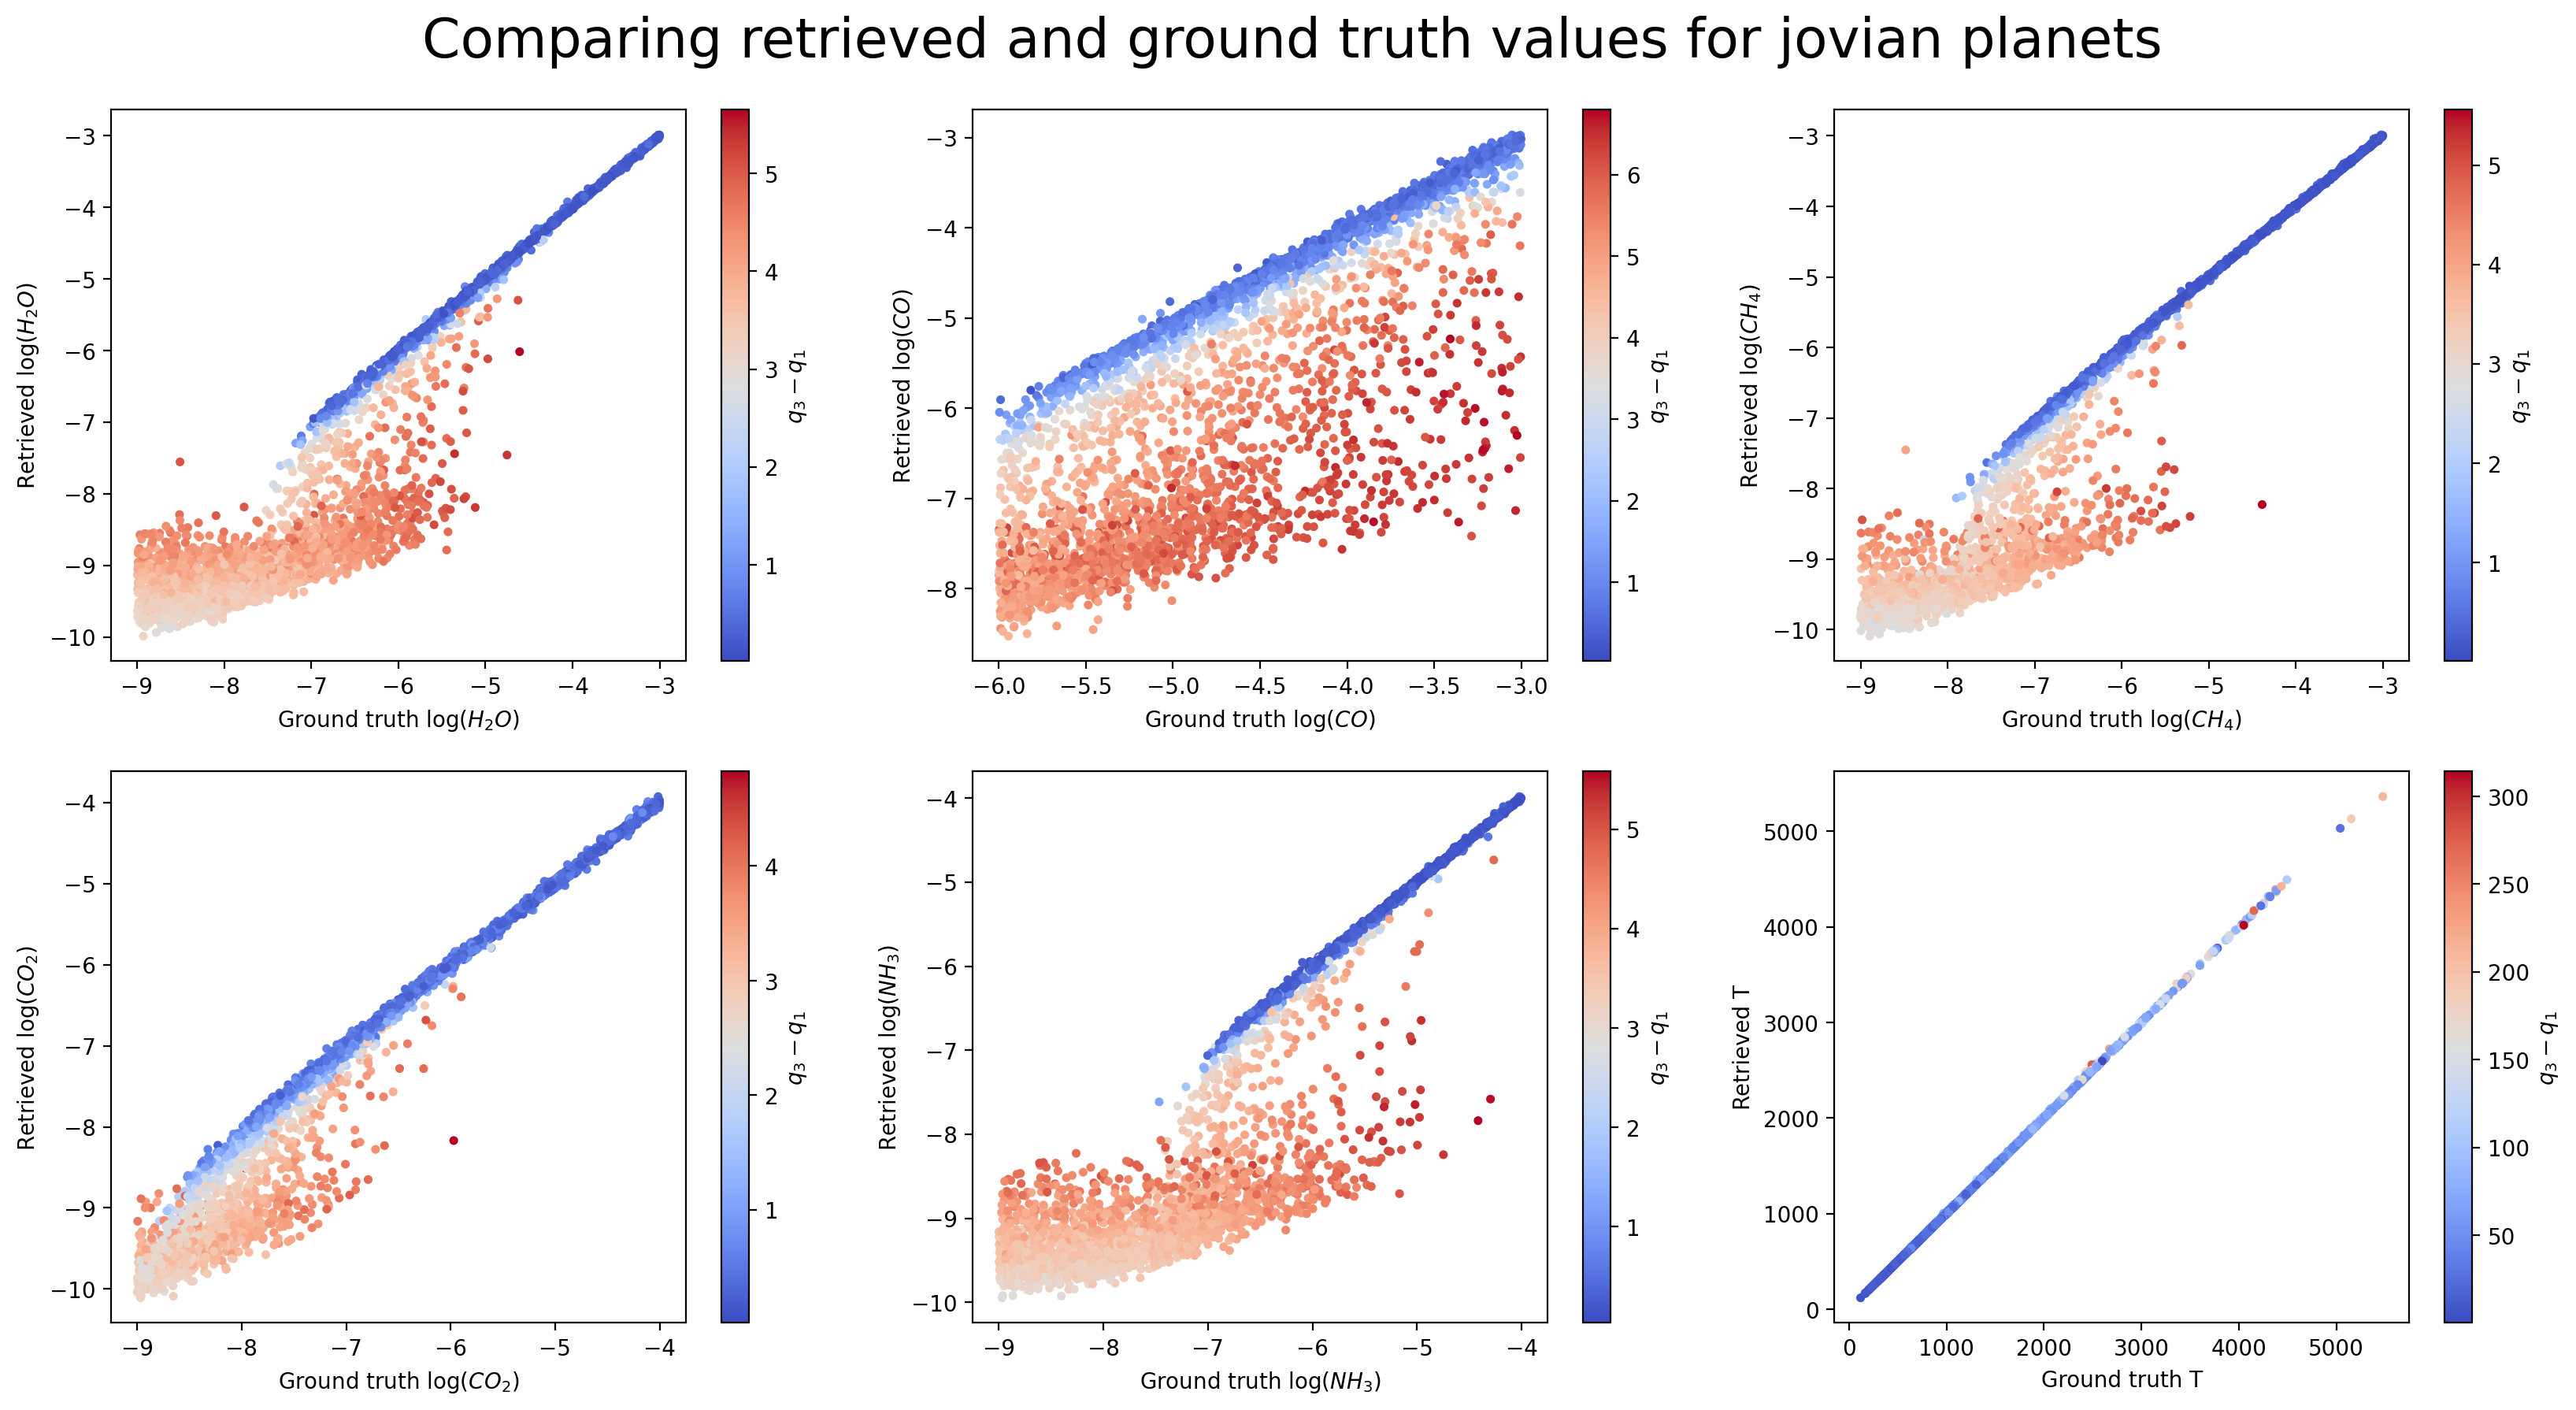

In [298]:
fig, ax = plt.subplots(2,3, figsize=(20, 10))

fig.suptitle("Comparing retrieved and ground truth values for jovian planets", fontsize=25, y=0.94)

cax = ax[0,0].scatter(jovians["log_H2O"], jovians["log_H2O_q2"], marker='.', c=jovians["log_H2O_q3"]-jovians["log_H2O_q1"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[0,0], label=r"$q_3-q_1$")
ax[0,0].set_ylabel(r"Retrieved log($H_2O$)")
ax[0,0].set_xlabel(r"Ground truth log($H_2O$)")

cax = ax[0,1].scatter(jovians["log_CO"], jovians["log_CO_q2"], marker='.', c=jovians["log_CO_q3"]-jovians["log_CO_q1"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[0,1], label=r"$q_3-q_1$")
ax[0,1].set_ylabel(r"Retrieved log($CO$)")
ax[0,1].set_xlabel(r"Ground truth log($CO$)")

cax = ax[0,2].scatter(jovians["log_CH4"], jovians["log_CH4_q2"], marker='.', c=jovians["log_CH4_q3"]-jovians["log_CH4_q1"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[0,2], label=r"$q_3-q_1$")
ax[0,2].set_ylabel(r"Retrieved log($CH_4$)")
ax[0,2].set_xlabel(r"Ground truth log($CH_4$)")

cax = ax[1,0].scatter(jovians["log_CO2"], jovians["log_CO2_q2"], marker='.', c=jovians["log_CO2_q3"]-jovians["log_CO2_q1"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[1,0], label=r"$q_3-q_1$")
ax[1,0].set_ylabel(r"Retrieved log($CO_2$)")
ax[1,0].set_xlabel(r"Ground truth log($CO_2$)")

cax = ax[1,1].scatter(jovians["log_NH3"], jovians["log_NH3_q2"], marker='.', c=jovians["log_NH3_q3"]-jovians["log_NH3_q1"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[1,1], label=r"$q_3-q_1$")
ax[1,1].set_ylabel(r"Retrieved log($NH_3$)")
ax[1,1].set_xlabel(r"Ground truth log($NH_3$)")

cax = ax[1,2].scatter(jovians["Dayside Emitting Temperature [K]"], jovians["T_q2"], marker='.', c=jovians["T_q3"]-jovians["T_q1"], cmap="coolwarm")
plt.colorbar(cax, ax=ax[1,2], label=r"$q_3-q_1$")
ax[1,2].set_ylabel(r"Retrieved T")
ax[1,2].set_xlabel(r"Ground truth T")



plt.show()

In [ ]:
jovians

,planet_ID,Dayside Emitting Temperature [K],log_H2O,log_CO2,log_CH4,log_CO,log_NH3,planet_ID,T_q1,T_q2,...,NH3 accuracy,CO precision,CO2 precision,H2O precision,CH4 precision,NH3 precision,Observations,Average TSM one transit,Average TSM,H2O precision single transit
3,3,1370.906116,-7.639372,-5.877303,-4.476840,-5.200010,-6.240726,3,1357.964612,1382.813499,...,0.979171,224.823915,0.390232,52.658946,0.113894,17.334721,49795.0,0.031369,7.000023,0.235982
8,8,1894.426237,-4.563467,-4.446741,-5.544289,-4.365387,-8.544595,8,1861.275569,1898.283858,...,0.674785,325.701086,0.344658,0.178268,0.335668,75.450330,42.0,1.086627,7.042150,0.027507
9,9,1398.904600,-3.197861,-5.635948,-7.961980,-3.112749,-7.210507,9,1366.710997,1395.927137,...,0.977984,78.336874,0.765829,0.288544,63.578228,65.885008,6.0,3.040484,7.447633,0.117798
21,21,1330.546342,-4.418341,-8.844871,-5.358944,-4.825542,-5.816142,21,1310.402162,1338.415614,...,0.422903,50.940539,9.720604,0.238893,0.273813,1.067852,34.0,1.209137,7.050422,0.040970
26,26,2500.299714,-4.739077,-6.047558,-5.861048,-3.345449,-4.963589,26,2449.927697,2535.623026,...,0.019732,3.516991,0.638127,0.374933,73.909483,0.377880,1.0,11.352401,11.352401,0.374933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91375,91375,1769.198104,-3.730302,-7.953726,-5.083220,-4.452745,-7.240038,91375,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.227051,7.215906,NaN
91378,91378,1698.848691,-5.326884,-4.051950,-8.780949,-5.076256,-6.419234,91378,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,98085.0,0.022351,7.000018,NaN
91380,91380,2088.716171,-5.474294,-4.393825,-3.327021,-5.993589,-4.293326,91380,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,5.155360,7.290780,NaN
91387,91387,1230.274532,-5.610091,-7.173193,-5.096518,-3.397266,-4.400357,91387,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,26.0,1.384406,7.059112,NaN


In [ ]:
# plt.scatter(jovians["log CO2 accuracy"], jovians["TSM"], marker='.')
# plt.yscale("log")
# plt.xscale("log")
# plt.show()

KeyError: 'log CO2 accuracy'

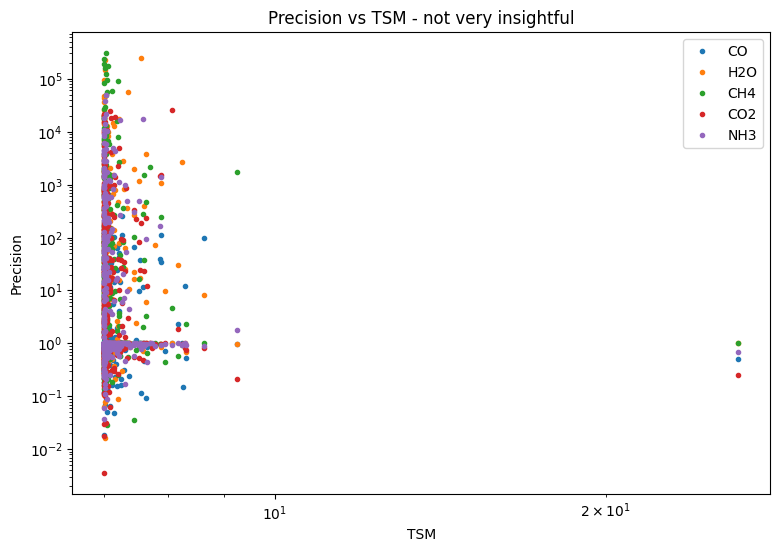

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))

plt.plot(red["Average TSM"], red["log CO2 precision"], marker='.', linestyle='None', label="CO")
plt.plot(red["Average TSM"], red["log H2O precision"], marker='.', linestyle='None', label="H2O")
plt.plot(red["Average TSM"], red["log CH4 precision"], marker='.', linestyle='None', label="CH4")
plt.plot(red["Average TSM"], red["log CO2 precision"], marker='.', linestyle='None', label="CO2")
plt.plot(red["Average TSM"], red["log NH3 precision"], marker='.', linestyle='None', label="NH3")

plt.ylabel("Precision")
plt.xlabel("TSM")

plt.title("Precision vs TSM - not very insightful")
plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()

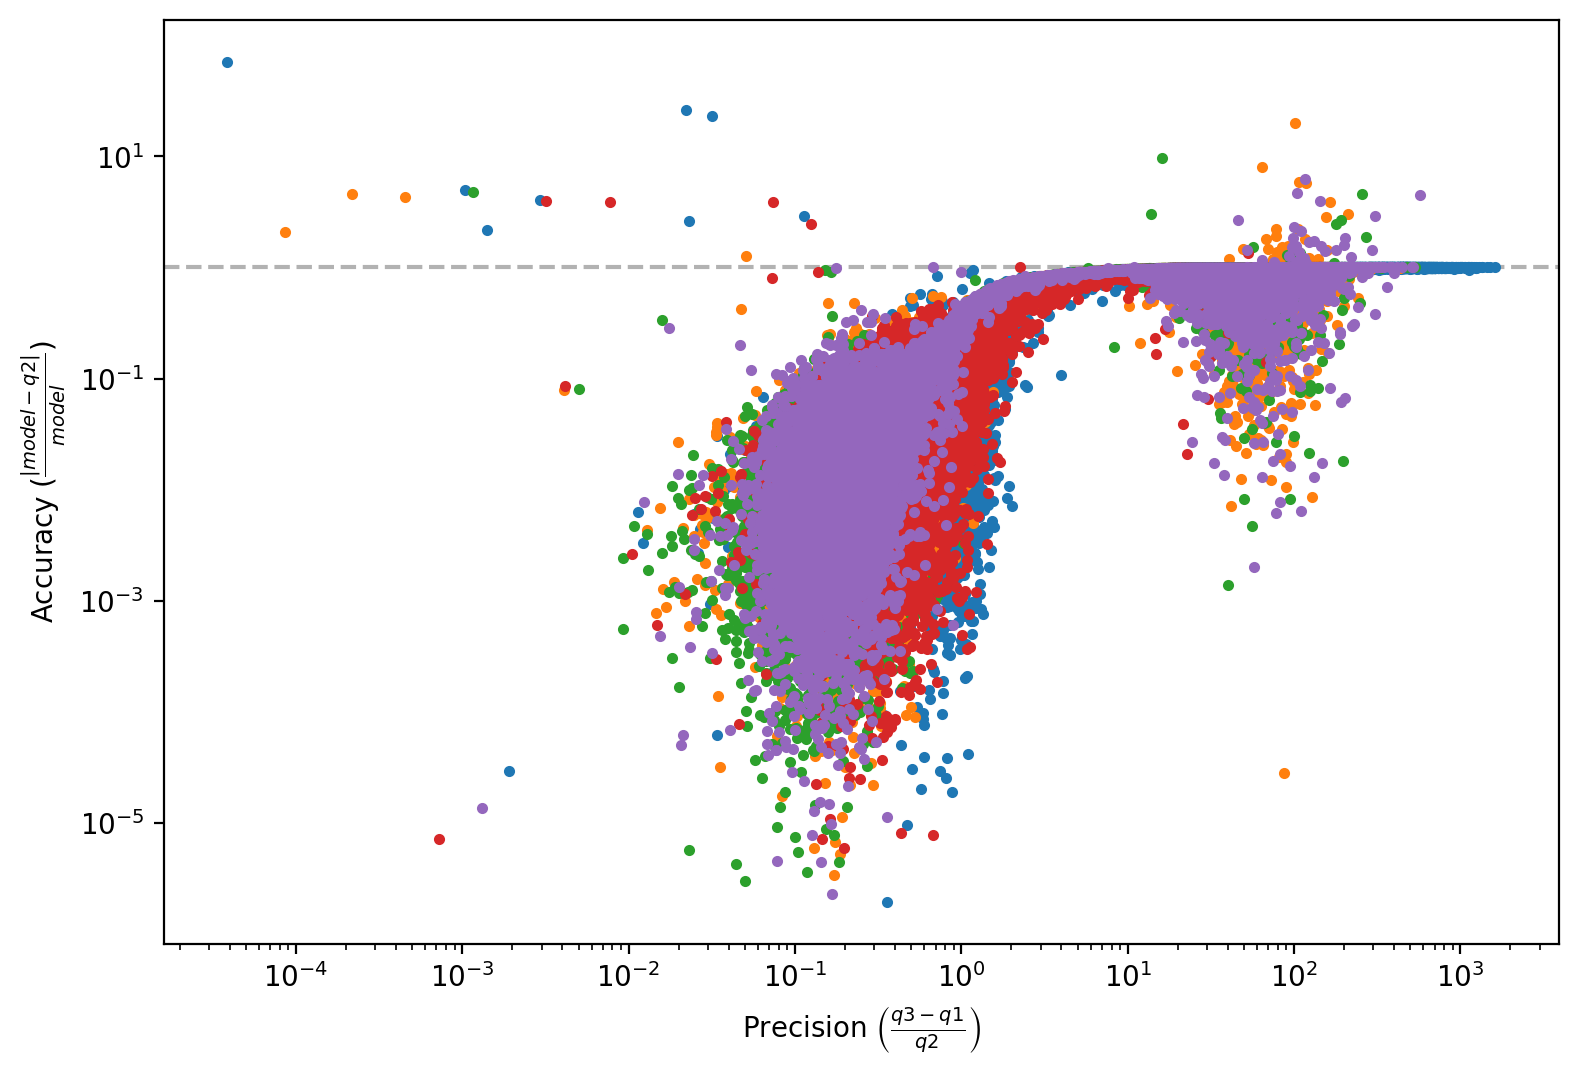

In [133]:
fig, ax = plt.subplots(figsize=(9,6))

plt.axhline(1, color='black', linestyle='--', alpha=0.3, zorder=0)

plt.scatter(df["log CO2 precision"], df["log CO accuracy"], marker='.', label="CO")
plt.scatter(df["log H2O precision"], df["log H2O accuracy"], marker='.', label="H2O")
plt.scatter(df["log CH4 precision"], df["log CH4 accuracy"], marker='.', label="CH4")
plt.scatter(df["log CO2 precision"], df["log CO2 accuracy"], marker='.', label="CO2")
plt.scatter(df["log NH3 precision"], df["log NH3 accuracy"], marker='.', label="NH3")

plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"Precision $\left(\frac{q3 - q1}{q2}\right)$")
plt.ylabel(r"Accuracy ($\frac{|model - q2|}{model}$)")

plt.show()

In [11]:
nir.table

,Unnamed: 0,Planet Name,H2O_model,CO2_model,CH4_model,CO_model,NH3_model,Star Distance [pc],star_magnitudeK,star_mass,...,TSM Estimate 1.61-1.695um,Transit Flux Ratio 1.695-1.78um,Noise Estimate 1.695-1.78um,TSM Estimate 1.695-1.78um,Transit Flux Ratio 1.78-1.865um,Noise Estimate 1.78-1.865um,TSM Estimate 1.78-1.865um,Transit Flux Ratio 1.865-1.95um,Noise Estimate 1.865-1.95um,TSM Estimate 1.865-1.95um
0,0,0,4.167630e-07,2.677037e-07,3.406210e-04,0.000280,9.134829e-07,705.851,1.000,2.688846,...,2.688146,0.000128,0.000051,2.526722,0.000128,0.000054,2.380410,0.000128,0.000057,2.247364
1,1,1,1.712960e-06,8.073855e-06,4.071083e-07,0.000097,2.311151e-06,1008.790,12.228,1.160000,...,0.283038,0.000035,0.000131,0.268087,0.000035,0.000138,0.254301,0.000035,0.000145,0.241576
2,2,2,1.523631e-08,8.624353e-05,4.414573e-04,0.000466,5.147188e-06,1175.220,13.771,1.030000,...,0.199540,0.000052,0.000275,0.189301,0.000052,0.000290,0.179824,0.000052,0.000304,0.171045
3,3,3,7.105252e-05,3.042866e-08,1.036978e-05,0.000118,6.534867e-06,758.199,1.000,0.849800,...,2.455314,0.000836,0.000358,2.333891,0.000836,0.000376,2.220929,0.000836,0.000395,2.115837
4,4,4,4.935057e-08,1.418218e-06,1.362163e-05,0.000006,6.960358e-08,769.200,13.001,0.910000,...,0.195612,0.000072,0.000385,0.185884,0.000072,0.000405,0.176841,0.000072,0.000425,0.168434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,495,7.951718e-07,8.586128e-05,1.241272e-09,0.000073,5.764585e-07,107.898,7.629,1.150000,...,8.157213,0.000117,0.000015,7.722998,0.000117,0.000016,7.323065,0.000117,0.000017,6.954220
496,496,496,1.363287e-08,2.282076e-05,3.751730e-08,0.000003,1.315496e-09,527.321,12.567,0.790000,...,0.184178,0.000032,0.000181,0.175264,0.000032,0.000190,0.166946,0.000032,0.000199,0.159188
497,497,497,9.710380e-04,1.071085e-06,6.854091e-08,0.000017,3.176220e-05,472.297,1.000,1.007400,...,2.789223,0.000292,0.000110,2.646049,0.000292,0.000116,2.513529,0.000292,0.000122,2.390785
498,498,498,1.832573e-06,5.215211e-07,6.881800e-07,0.000011,1.870584e-05,474.861,11.001,1.040000,...,0.513406,0.000050,0.000102,0.486786,0.000050,0.000107,0.462181,0.000050,0.000113,0.439418


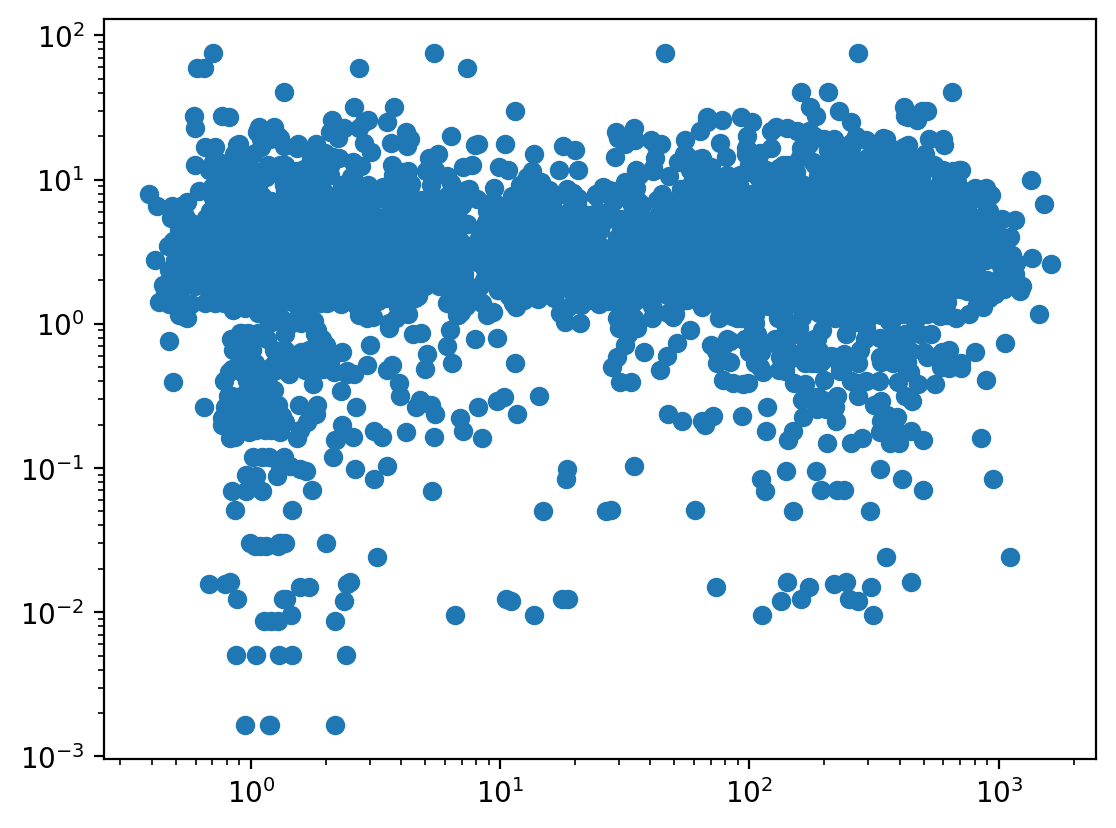

In [135]:
plt.scatter(nir.target_list["log CO2 precision"], nir.table["TSM Estimate 1.695-1.78um"], label="NIRSpec")

plt.yscale("log")
plt.xscale("log")

In [48]:
# CO2
co2 = red[["Planet Name", "CO2_model"]]
co2 = pd.concat((co2, nir.getParam("TSM", 1.6, names=False)), axis=1)
co2 = pd.concat((co2, a0.getParam("TSM", 2.0, names=False)), axis=1) 
co2 = pd.concat((co2, a1.getParam("TSM", 4.3, names=False)), axis=1)
co2["TSM avg"] = co2.filter(like='TSM').mean(1)
co2

co = red[["Planet Name", "CO_model"]]
co = pd.concat((co, a0.getParam("TSM", 2.35, names=False)), axis=1) 
co = pd.concat((co, a1.getParam("TSM", 4.6, names=False)), axis=1)
co["TSM avg"] = co.filter(like='TSM').mean(1)
co

h2o = red[["Planet Name", "H2O_model"]]
h2o = pd.concat((h2o, a0.getParam("TSM", 2.9, names=False)), axis=1) 
h2o = pd.concat((h2o, a1.getParam("TSM", 6, names=False)), axis=1)
h2o["TSM avg"] = h2o.filter(like='TSM').mean(1)
h2o

co = red[["Planet Name", "CO_model"]]
co = pd.concat((co, a0.getParam("TSM", 2.35, names=False)), axis=1) 
co = pd.concat((co, a1.getParam("TSM", 4.6, names=False)), axis=1)
co["TSM avg"] = co.filter(like='TSM').mean(1)
co

# co = red[["Planet Name", "CO_model"]]
# co = pd.concat((co, a0.getParam("TSM", 2.35, names=False)), axis=1) 
# co = pd.concat((co, a1.getParam("TSM", 4.6, names=False)), axis=1)
# co["TSM avg"] = co.filter(like='TSM').mean(1)
# co

,Planet Name,CO_model,TSM Estimate 2.34-2.379um,TSM Estimate 4.29-4.68um,TSM avg
0,0,0.000280,0.943931,1.242262,1.093096
1,1,0.000097,0.104004,0.143272,0.123638
2,2,0.000466,0.074017,0.102924,0.088470
3,3,0.000118,0.921350,1.295893,1.108622
4,4,0.000006,0.073277,0.102890,0.088083
...,...,...,...,...,...
496,496,0.000003,0.069565,0.098478,0.084021
497,497,0.000017,1.034505,1.438340,1.236422
498,498,0.000011,0.189806,0.263058,0.226432
499,499,0.000003,0.393888,0.540721,0.467304


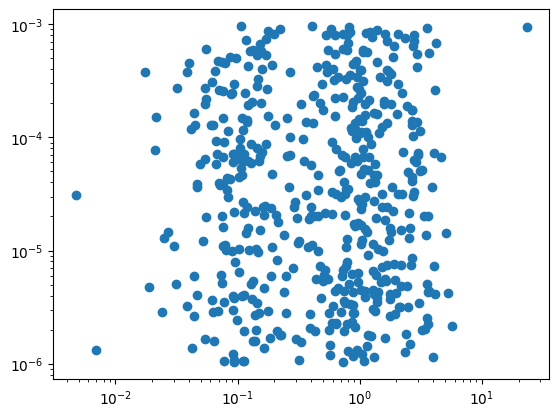

In [52]:
plt.scatter(co["TSM Estimate 2.34-2.379um"], co["CO_model"])
plt.yscale('log')
plt.xscale('log')

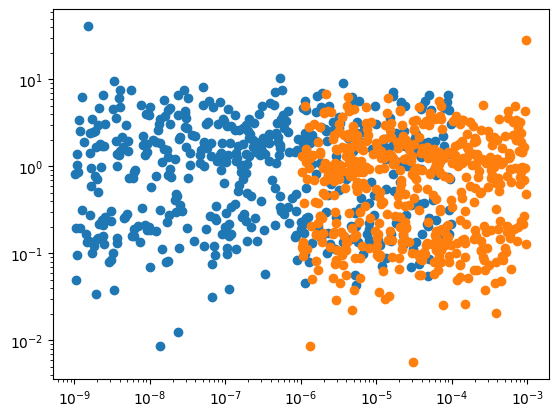

In [43]:
fig, ax = plt.subplots()

ax.scatter(co2["CO2_model"], co2["TSM avg"])
ax.scatter(co["CO_model"], co["TSM avg"])

ax.set_yscale('log')
ax.set_xscale('log')

plt.show()

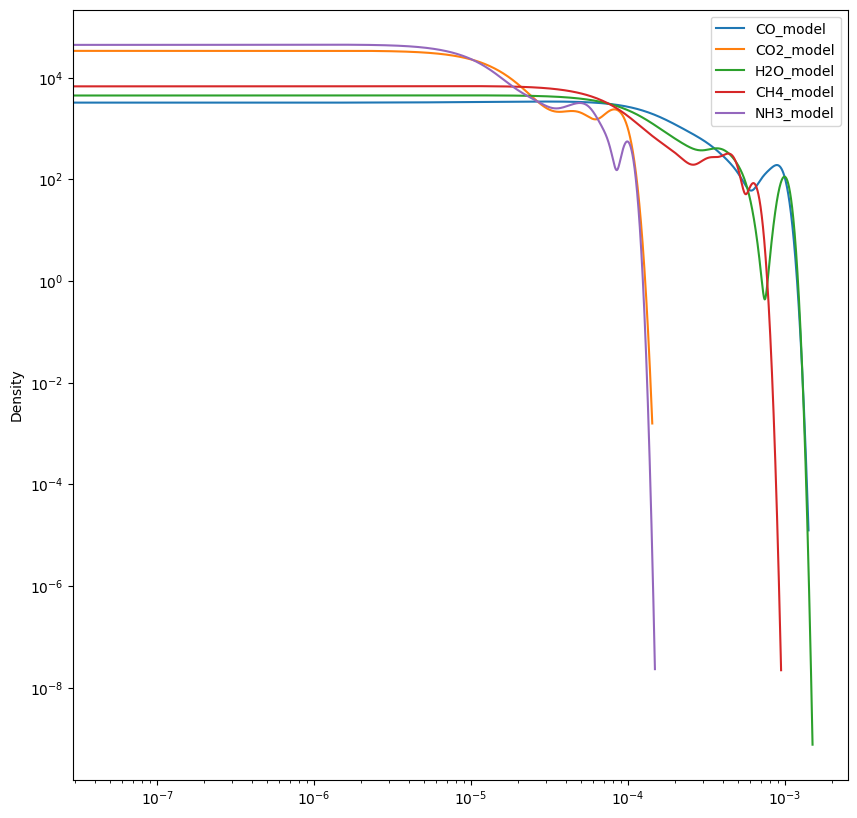

In [46]:
fig, ax = plt.subplots(figsize=(10,10))
tab = nir.table
# ax.scatter(tab["TSM Estimate 1.1-1.185um"], tab["CO_model"])
# ax.scatter(tab["TSM Estimate 1.1-1.185um"], tab["CO2_model"])
# ax.scatter(tab["TSM Estimate 1.1-1.185um"], tab["H2O_model"])
# ax.scatter(tab["TSM Estimate 1.1-1.185um"], tab["NH3_model"])
# ax.scatter(tab["TSM Estimate 1.1-1.185um"], tab["CH4_model"])

tab.plot("TSM Estimate 1.1-1.185um", "CO_model", kind=, ax=ax)
tab.plot("TSM Estimate 1.1-1.185um", "CO2_model", kind='kde', ax=ax)
tab.plot("TSM Estimate 1.1-1.185um", "H2O_model", kind='kde', ax=ax)
tab.plot("TSM Estimate 1.1-1.185um", "CH4_model", kind='kde', ax=ax)
tab.plot("TSM Estimate 1.1-1.185um", "NH3_model", kind='kde', ax=ax)

ax.set_yscale('log')
ax.set_xscale('log')


plt.show()

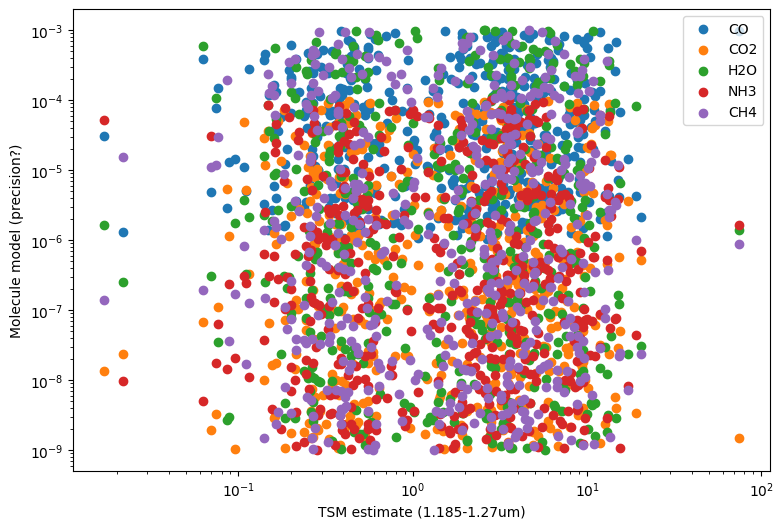

In [47]:
fig, ax = plt.subplots(figsize=(9,6))
tab = nir.table
ax.scatter(tab["TSM Estimate 1.185-1.27um"], tab["CO_model"], label="CO")
ax.scatter(tab["TSM Estimate 1.185-1.27um"], tab["CO2_model"], label="CO2")
ax.scatter(tab["TSM Estimate 1.185-1.27um"], tab["H2O_model"], label="H2O")
ax.scatter(tab["TSM Estimate 1.185-1.27um"], tab["NH3_model"], label="NH3")
ax.scatter(tab["TSM Estimate 1.185-1.27um"], tab["CH4_model"], label="CH4")

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel("TSM estimate (1.185-1.27um)")
ax.set_ylabel("Molecule model (precision?)")

ax.legend()

plt.show()

In [18]:
nirspec = Telescope("Ariel NIRSpec", 1, (1.10, 1.95), 10, 0.27, df, "ML_targetlist_level1_cleaned")
airs1 = Telescope("Ariel AIRS CH0", 1, (1.95, 3.9), 50, 0.18, df, "ML_targetlist_level1_cleaned")
airs2 = Telescope("Ariel AIRS CH1", 1, (3.9, 7.8), 10, 0.18, df, "ML_targetlist_level1_cleaned")

In [20]:
getTSMs(nirspec)

In [24]:
getTSMs(airs1)

In [25]:
getTSMs(airs2)

In [29]:
tsms = pd.concat([nirspec.table.filter(like='TSM'), airs1.table.filter(like='TSM'), airs2.table.filter(like='TSM')], axis=1)
avg = tsms.mean(axis=1)
avg

0         1.102529
1         0.119715
2         0.084963
3         1.054171
4         0.083880
            ...   
105882    1.102563
105883    1.689998
105884    0.109937
105885    1.093816
105886    0.487228
Length: 105887, dtype: float64

In [50]:
df.columns

Index(['Unnamed: 0', 'Planet Name', 'H2O_model', 'CO2_model', 'CH4_model',
       'CO_model', 'NH3_model', 'Star Distance [pc]', 'star_magnitudeK',
       'star_mass', 'star_mass_kg', 'star_metallicity', 'Star Radius [Rs]',
       'star_radius_m', 'star_type', 'Star Temperature [K]', 'Planet Albedo',
       'planet_impact_param', 'planet_mass_kg', 'Planet Period [days]',
       'Planet Semi-major Axis [au]', 'Planet Mass [Mjup]',
       'Planet Radius [Rjup]', 'planet_type', 'planet_radius_m',
       'planet_surface_gravity', 'Transit Duration [hrs]', 'planet_temp_model',
       'instrument_nobs', 'Eclipse Duration [hrs]', 'Mean Molecular Weight',
       'Planet Geometric Albedo', 'Heat Redistribution Factor',
       'Dayside Emitting Temperature [K]'],
      dtype='object')

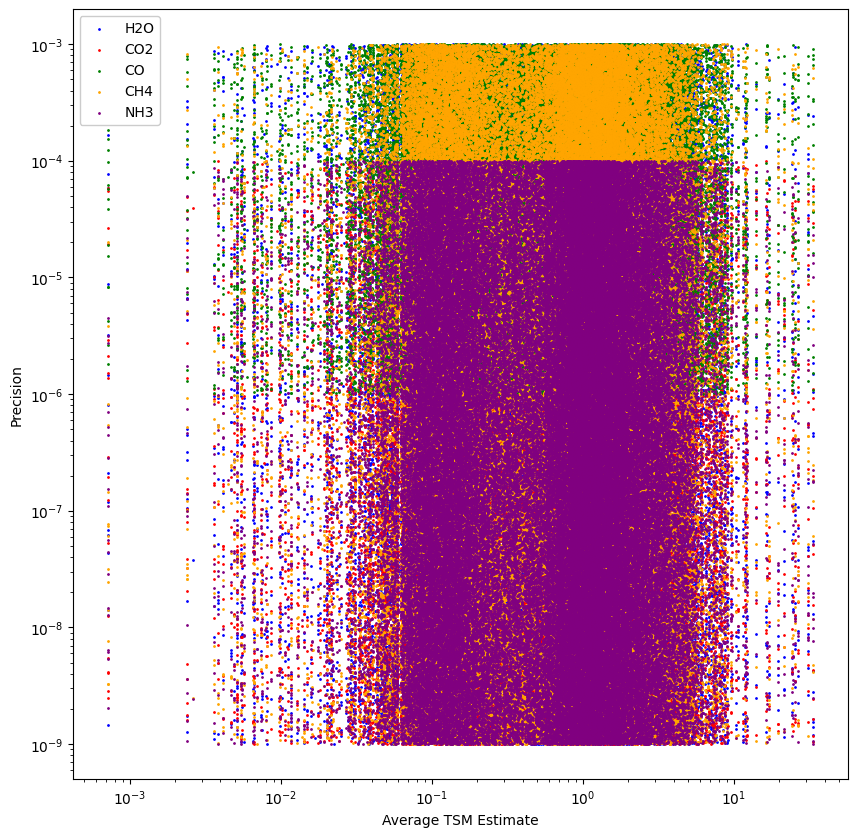

In [53]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_yscale('log')
ax.set_xscale('log')

plt.scatter(x=avg, y=df["H2O_model"], s=1, c='blue', label="H2O")
plt.scatter(x=avg, y=df["CO2_model"], s=1, c='red', label="CO2")
plt.scatter(x=avg, y=df["CO_model"], s=1, c='green', label="CO")
plt.scatter(x=avg, y=df["CH4_model"], s=1, c='orange', label="CH4")
plt.scatter(x=avg, y=df["NH3_model"], s=1, c='purple', label="NH3")

ax.set_xlabel("Average TSM Estimate")
ax.set_ylabel("Precision")

plt.legend(loc="upper left", framealpha=1)

plt.show()

In [51]:
df

,Unnamed: 0,Planet Name,H2O_model,CO2_model,CH4_model,CO_model,NH3_model,Star Distance [pc],star_magnitudeK,star_mass,...,planet_radius_m,planet_surface_gravity,Transit Duration [hrs],planet_temp_model,instrument_nobs,Eclipse Duration [hrs],Mean Molecular Weight,Planet Geometric Albedo,Heat Redistribution Factor,Dayside Emitting Temperature [K]
0,0,0,4.167630e-07,2.677037e-07,3.406210e-04,0.000280,9.134829e-07,705.8510,1.000,2.688846,...,1.258883,8.008170,2.427000,2224.531730,111.0,2.427000,2.3,0.25,0.8,2186.491528
1,1,1,1.712960e-06,8.073855e-06,4.071083e-07,0.000097,2.311151e-06,1008.7900,12.228,1.160000,...,0.267000,10.083029,6.075903,853.088814,18387.0,6.075903,2.3,0.25,0.8,838.500723
2,2,2,1.523631e-08,8.624353e-05,4.414573e-04,0.000466,5.147188e-06,1175.2200,13.771,1.030000,...,0.272000,10.050762,5.287446,459.835595,101337.0,5.287446,2.3,0.25,0.8,481.280092
3,3,3,7.105252e-05,3.042866e-08,1.036978e-05,0.000118,6.534867e-06,758.1990,1.000,0.849800,...,0.934320,6.936464,1.573366,1490.487796,313.0,1.573366,2.3,0.25,0.8,1464.999980
4,4,4,4.935057e-08,1.418218e-06,1.362163e-05,0.000006,6.960358e-08,769.2000,13.001,0.910000,...,0.194000,11.195952,1.818750,749.616817,60412.0,1.818750,2.3,0.25,0.8,736.798131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105882,105882,105882,2.454195e-06,6.711299e-08,8.007227e-06,0.000401,3.977802e-05,491.6220,1.000,1.031275,...,1.623787,18.721422,2.426000,1230.274532,166.0,2.426000,2.3,0.25,0.8,1209.236445
105883,105883,105883,4.939854e-09,1.742973e-05,1.086380e-04,0.000713,4.571026e-06,316.2280,1.000,1.229375,...,1.892161,21.320410,3.750000,1218.571572,49.0,3.750000,2.3,0.25,0.8,1197.733610
105884,105884,105884,3.883494e-06,2.884210e-09,2.066026e-09,0.000010,8.653940e-09,1050.6400,13.308,0.940000,...,0.184000,11.274586,3.140940,1125.496097,47978.0,3.140940,2.3,0.25,0.8,1106.249755
105885,105885,105885,5.242032e-04,5.177775e-06,6.952050e-04,0.000019,1.162402e-05,90.8693,1.000,0.739387,...,0.221741,10.876742,2.337662,818.176365,92.0,2.337662,2.3,0.25,0.8,804.185288


In [ ]:
nirspec.target_list[""]

In [6]:
df = pd.read_csv("target_lists/ML_targetlist_level1.csv")
cleanTargetList(df, separate_errors=False)

,Planet Name,H2O_model,CO2_model,CH4_model,CO_model,NH3_model,Star Distance [pc],star_magnitudeK,star_mass,star_mass_kg,...,planet_type,planet_radius_m,planet_surface_gravity,Transit Duration [hrs],planet_temp_model,instrument_nobs,Eclipse Duration [hrs],Mean Molecular Weight,Planet Geometric Albedo,Heat Redistribution Factor
0,0,4.167630e-07,2.677037e-07,3.406210e-04,0.000280,9.134829e-07,705.8510,1.000,2.688846,5.346528e+30,...,PlanetCata+Planet,1.258883,8.008170,2.427000,2224.531730,111.0,2.427000,2.3,0.25,0.8
1,1,1.712960e-06,8.073855e-06,4.071083e-07,0.000097,2.311151e-06,1008.7900,12.228,1.160000,2.306555e+30,...,PlanetCata+Planet,0.267000,10.083029,6.075903,853.088814,18387.0,6.075903,2.3,0.25,0.8
2,2,1.523631e-08,8.624353e-05,4.414573e-04,0.000466,5.147188e-06,1175.2200,13.771,1.030000,2.048062e+30,...,PlanetCata+Planet,0.272000,10.050762,5.287446,459.835595,101337.0,5.287446,2.3,0.25,0.8
3,3,7.105252e-05,3.042866e-08,1.036978e-05,0.000118,6.534867e-06,758.1990,1.000,0.849800,1.689751e+30,...,PlanetCata+Planet,0.934320,6.936464,1.573366,1490.487796,313.0,1.573366,2.3,0.25,0.8
4,4,4.935057e-08,1.418218e-06,1.362163e-05,0.000006,6.960358e-08,769.2000,13.001,0.910000,1.809453e+30,...,PlanetCata+Planet,0.194000,11.195952,1.818750,749.616817,60412.0,1.818750,2.3,0.25,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105882,105882,2.454195e-06,6.711299e-08,8.007227e-06,0.000401,3.977802e-05,491.6220,1.000,1.031275,2.050597e+30,...,PlanetCata+Planet,1.623787,18.721422,2.426000,1230.274532,166.0,2.426000,2.3,0.25,0.8
105883,105883,4.939854e-09,1.742973e-05,1.086380e-04,0.000713,4.571026e-06,316.2280,1.000,1.229375,2.444501e+30,...,PlanetCata+Planet,1.892161,21.320410,3.750000,1218.571572,49.0,3.750000,2.3,0.25,0.8
105884,105884,3.883494e-06,2.884210e-09,2.066026e-09,0.000010,8.653940e-09,1050.6400,13.308,0.940000,1.869105e+30,...,PlanetCata+Planet,0.184000,11.274586,3.140940,1125.496097,47978.0,3.140940,2.3,0.25,0.8
105885,105885,5.242032e-04,5.177775e-06,6.952050e-04,0.000019,1.162402e-05,90.8693,1.000,0.739387,1.470204e+30,...,PlanetCata+Planet,0.221741,10.876742,2.337662,818.176365,92.0,2.337662,2.3,0.25,0.8


In [4]:
Ariel.setTargetList("ML_targetlist_level1_cleaned")

In [18]:
Ariel.constructArielInstruments("ML_targetlist_level1_cleaned")

Successfully updated the Ariel.instruments dictionary with the newly constructed Ariel instruments.


In [26]:
Ariel.getTieredInstruments('tier 1')
Ariel.setTargetList("ML_targetlist_level1_cleaned")
Ariel.getInstrument('Ariel NIRSpec R=1')

KeyError: 'Ariel_MCS_Known_2024-03-27'

In [23]:
tier = Ariel.getTieredInstruments("ML_targetlist_level1_cleaned")

TypeError: 'NoneType' object is not subscriptable

In [19]:
Ariel.constructObservationTable("ML_targetlist_level1_cleaned")

ZeroDivisionError: division by zero